In [1]:
import pandas as pd
import numpy as np
import os

# ============================================================
# CONFIGURACIÓN - NUEVA CARPETA DE SALIDA
# ============================================================
datos_originales = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO"
base_resultados = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2"
os.makedirs(base_resultados, exist_ok=True)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def encontrar_archivo(carpeta, inicio_nombre):
    for f in os.listdir(carpeta):
        if f.upper().replace(".CSV", "").startswith(inicio_nombre.upper()):
            return os.path.join(carpeta, f)
    raise FileNotFoundError(f"No se encontró {inicio_nombre} en {carpeta}")

def leer_csv_inei(ruta):
    for sep in [",", ";"]:
        for enc in ["utf-8-sig", "latin1"]:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False, dtype=str)
                if len(df.columns) > 1:
                    df.columns = df.columns.str.strip()
                    return df
            except Exception:
                pass
    raise ValueError(f"No se pudo leer el archivo: {ruta}")

def to_num(serie):
    return pd.to_numeric(serie, errors="coerce")

def construir_llave_persona(df, llaves=None, nombre="llave_persona"):
    if llaves is None:
        llaves = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    df = df.copy()
    for c in llaves:
        df[f"_{c}_k"] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype(str)
    df[nombre] = df[[f"_{c}_k" for c in llaves]].agg("-".join, axis=1)
    return df.drop(columns=[f"_{c}_k" for c in llaves])

# ============================================================
# COLUMNAS PARA USO DE BILLETERA (VERSIÓN CORRECTA)
# ============================================================
COLS_USO_BILLETERA = [f"P558H{i}_7" for i in range(1, 13)]

def reparar_variables(df):
    df = df.copy()

    df["Edad"] = to_num(df["P208A"]) if "P208A" in df.columns else df.get("Edad")
    df["P507_num"] = to_num(df["P507"])
    df["P510A1_num"] = to_num(df["P510A1"])
    df["P511A_num"] = to_num(df["P511A"])

    # --- Ocupado ---
    df["Ocupado"] = df["P507_num"].notna().astype(int)

    # --- Informalidad ---
    tfnr = df["P507_num"] == 5
    trab_hogar = df["P507_num"] == 6
    sin_sunat = (df["P507_num"] == 2) & (df["P510A1_num"] == 3)
    dependiente = df["P507_num"].isin([3, 4])
    sin_contrato = df["P511A_num"] == 7

    df["Informal"] = (
        sin_sunat.fillna(False)
        | tfnr.fillna(False)
        | trab_hogar.fillna(False)
        | (dependiente & sin_contrato.fillna(False))
    ).astype(int)
    df.loc[df["Ocupado"] == 0, "Informal"] = pd.NA

    # --- Crédito formal ---
    df["P558E1_4"] = to_num(df.get("P558E1_4")).fillna(0)
    df["P558E1_9"] = to_num(df.get("P558E1_9")).fillna(0)
    df["CreditoFormal"] = ((df["P558E1_4"] == 4) | (df["P558E1_9"] == 9)).astype(int)

    # --- Tenencia de billetera ---
    df["P558E1_8"] = to_num(df.get("P558E1_8")).fillna(0)
    df["TenenciaBilletera"] = (df["P558E1_8"] == 8).astype(int)

    # --- USO DE BILLETERA ---
    cols_uso_presentes = [c for c in COLS_USO_BILLETERA if c in df.columns]
    if cols_uso_presentes:
        uso_flags = pd.concat(
            [to_num(df[c]).fillna(0) == 7 for c in cols_uso_presentes], axis=1
        )
        df["UsoBilletera"] = uso_flags.any(axis=1).astype(int)
    else:
        df["UsoBilletera"] = pd.NA

    # --- Crédito informal ---
    if "P558G7" in df.columns:
        df["CreditoInformal"] = (to_num(df["P558G7"]).fillna(0) == 7).astype(int)

    return df

def construir_master(anio, carpetas):
    print(f"Cargando módulos {anio}...")

    ruta_200 = encontrar_archivo(*carpetas["Mod200"])
    df200 = leer_csv_inei(ruta_200)[["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P203", "P207", "P208A"]]

    ruta_300 = encontrar_archivo(*carpetas["Mod300"])
    df300 = leer_csv_inei(ruta_300)[["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P301A", "P301B"]]

    ruta_500 = encontrar_archivo(*carpetas["Mod500"])
    df500_full = leer_csv_inei(ruta_500)
    cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
                "P507", "P510A1", "P511A", "P512A",
                "P558E1_4", "P558E1_8", "P558E1_9", "P558G7"] + COLS_USO_BILLETERA
    df500 = df500_full[[c for c in cols_500 if c in df500_full.columns]]

    ruta_100 = encontrar_archivo(*carpetas["Mod100"])
    df100 = leer_csv_inei(ruta_100)
    cols_100 = ["CONGLOME", "VIVIENDA", "HOGAR", "DOMINIO", "ESTRATO", "PANEL"]
    for fac in ["FACTOR", "FACPOB", "FACTOR07"]:
        if fac in df100.columns:
            cols_100.append(fac)
            break
    df100 = df100[cols_100]

    ruta_sum = encontrar_archivo(*carpetas["Sumaria"])
    df_sum = leer_csv_inei(ruta_sum)
    
    # ============================================================
    # MODIFICACIÓN: SELECCIONAR INGHOG2D Y GASHOG2D
    # ============================================================
    cols_sum = ["CONGLOME", "VIVIENDA", "HOGAR"]
    
    # Buscar variables de ingreso y gasto en la Sumaria
    # Primero intentar con la versión 2D (recomendada)
    ingreso_col = None
    gasto_col = None
    
    # Ingreso: INGHOG2D o INGHOG1D
    for col in ["INGHOG2D", "INGHOG1D", "INGHOG2", "INGHOG1"]:
        if col in df_sum.columns:
            ingreso_col = col
            break
    
    # Gasto: GASHOG2D o GASHOG1D
    for col in ["GASHOG2D", "GASHOG1D", "GASHOG2", "GASHOG1"]:
        if col in df_sum.columns:
            gasto_col = col
            break
    
    # Renombrar a nombres estándar
    if ingreso_col:
        df_sum = df_sum.rename(columns={ingreso_col: "INGHOG2D"})
        cols_sum.append("INGHOG2D")
        print(f"  ✓ Ingreso encontrado: {ingreso_col} → INGHOG2D")
    
    if gasto_col:
        df_sum = df_sum.rename(columns={gasto_col: "GASHOG2D"})
        cols_sum.append("GASHOG2D")
        print(f"  ✓ Gasto encontrado: {gasto_col} → GASHOG2D")
    
    # MIEPERHO o MIEMBRO
    for m in ["MIEPERHO", "MIEMBRO"]:
        if m in df_sum.columns:
            cols_sum.append(m)
            break
    
    df_sum = df_sum[cols_sum]

    llave_persona = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    llave_hogar = ["CONGLOME", "VIVIENDA", "HOGAR"]

    df = df200.merge(df300, on=llave_persona, how="left")
    df = df.merge(df500, on=llave_persona, how="left")
    df = df.merge(df100, on=llave_hogar, how="left")
    df = df.merge(df_sum, on=llave_hogar, how="left")

    df = construir_llave_persona(df)
    df = reparar_variables(df)

    # ============================================================
    # MODIFICACIÓN: CALCULAR INGRESO Y GASTO PER CÁPITA
    # ============================================================
    # Convertir a numérico
    df["INGHOG2D_num"] = to_num(df.get("INGHOG2D"))
    df["GASHOG2D_num"] = to_num(df.get("GASHOG2D"))
    df["MIEPERHO_num"] = to_num(df.get("MIEPERHO"))
    
    # Calcular per cápita
    df["ingreso_percapita"] = df["INGHOG2D_num"] / df["MIEPERHO_num"]
    df["gasto_percapita"] = df["GASHOG2D_num"] / df["MIEPERHO_num"]
    
    print(f"  ✓ Ingreso per cápita calculado (media: {df['ingreso_percapita'].mean():.2f})")
    print(f"  ✓ Gasto per cápita calculado (media: {df['gasto_percapita'].mean():.2f})")

    ruta_salida = os.path.join(base_resultados, f"MASTER_{anio}.csv")
    df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
    print(f"✅ Guardado: {ruta_salida}  ({df.shape[0]:,} x {df.shape[1]})")
    return df

# ============================================================
# 1. CONSTRUIR MASTER 2024 y 2025
# ============================================================

carpetas_2024 = {
    "Mod100": (os.path.join(datos_originales, "966-Modulo01"), "Enaho01-2024-100"),
    "Mod200": (os.path.join(datos_originales, "966-Modulo02"), "Enaho01-2024-200"),
    "Mod300": (os.path.join(datos_originales, "966-Modulo03"), "Enaho01A-2024-300"),
    "Mod500": (os.path.join(datos_originales, "966-Modulo05"), "Enaho01a-2024-500"),
    "Sumaria": (os.path.join(datos_originales, "966-Modulo34"), "Sumaria-2024-12g"),
}
df_master_2024 = construir_master("2024", carpetas_2024)

carpetas_2025 = {
    "Mod100": (os.path.join(datos_originales, "1031-Modulo01-2025"), "Enaho01-2025-100"),
    "Mod200": (os.path.join(datos_originales, "1031-Modulo02-2025"), "Enaho01-2025-200"),
    "Mod300": (os.path.join(datos_originales, "1031-Modulo03-2025"), "Enaho01A-2025-300"),
    "Mod500": (os.path.join(datos_originales, "1031-Modulo05-2025"), "Enaho01a-2025-500"),
    "Sumaria": (os.path.join(datos_originales, "1031-Modulo34-2025"), "Sumaria-2025-12g"),
}
df_master_2025 = construir_master("2025", carpetas_2025)

# ============================================================
# 2. CONSTRUIR PANEL
# ============================================================

df24 = pd.read_csv(os.path.join(base_resultados, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)
df25 = pd.read_csv(os.path.join(base_resultados, "MASTER_2025.csv"), encoding="utf-8-sig", low_memory=False)

df24 = construir_llave_persona(df24)
df25 = construir_llave_persona(df25)

match = df24[["llave_persona"]].drop_duplicates().merge(
    df25[["llave_persona"]].drop_duplicates(), on="llave_persona", how="inner"
)

cols_2024 = ["llave_persona", "P203", "P207", "Edad", "Ocupado", "Informal",
             "TenenciaBilletera", "UsoBilletera", "CreditoFormal", "FACTOR07", "P301A",
             "ESTRATO", "DOMINIO", "MIEPERHO", "CONGLOME",
             "ingreso_percapita", "gasto_percapita"]  # AÑADIDO
df_2024_sub = df24[df24["llave_persona"].isin(match["llave_persona"])][cols_2024].rename(
    columns={"CreditoFormal": "CreditoFormal_2024",
             "ingreso_percapita": "ingreso_percapita_2024",
             "gasto_percapita": "gasto_percapita_2024"}
)

cols_2025 = ["llave_persona", "CreditoFormal", "ingreso_percapita", "gasto_percapita"]
if "CreditoInformal" in df25.columns:
    cols_2025.append("CreditoInformal")
df_2025_sub = df25[cols_2025].rename(
    columns={"CreditoFormal": "CreditoFormal_2025", 
             "CreditoInformal": "CreditoInformal_2025",
             "ingreso_percapita": "ingreso_percapita_2025",
             "gasto_percapita": "gasto_percapita_2025"}
)

panel_df = df_2024_sub.merge(df_2025_sub, on="llave_persona", how="left")
panel_df.to_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), index=False, encoding="utf-8-sig")
print(f"✅ PANEL_2024_2025.csv guardado ({panel_df.shape[0]:,} filas)")

# ============================================================
# 3. FILTRAR MUESTRA ANALÍTICA
# ============================================================

df = pd.read_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)

df["P203_num"] = pd.to_numeric(df["P203"], errors="coerce")
df["Ocupado_num"] = pd.to_numeric(df["Ocupado"], errors="coerce")
df["CreditoFormal_2024_num"] = pd.to_numeric(df["CreditoFormal_2024"], errors="coerce")
df["CreditoFormal_2025_num"] = pd.to_numeric(df["CreditoFormal_2025"], errors="coerce")
df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")

# Excluir códigos 99 en nivel educativo (P301A)
df = df[df["P301A_num"] != 99]

df = df[df["P203_num"] == 1]
df = df[df["Ocupado_num"] == 1]
df = df[df["CreditoFormal_2024_num"] == 0]
df = df.dropna(subset=["Informal_num", "TenenciaBilletera", "UsoBilletera", "P207", "Edad", "P301A"])

df["NuevoCredito"] = (df["CreditoFormal_2025_num"] == 1).astype(int)

# ============================================================
# 4. RENOMBRAR VARIABLES FINALES
# ============================================================

diccionario_renombres = {
    "llave_persona": "id_persona",
    "P203": "jefe_hogar",
    "P207": "sexo",
    "Edad": "edad",
    "P301A": "nivel_educativo",
    "Ocupado": "ocupado",
    "Informal": "trabajador_informal",
    "TenenciaBilletera": "tiene_billetera",
    "UsoBilletera": "usa_billetera",
    "CreditoFormal_2024": "credito_formal_2024",
    "CreditoFormal_2025": "credito_formal_2025",
    "CreditoInformal_2025": "credito_informal_2025",
    "NuevoCredito": "nuevo_credito_formal",
    "FACTOR07": "factor_expansion",
    "ESTRATO": "estrato",
    "DOMINIO": "dominio",
    "MIEPERHO": "miembros_hogar",
    "CONGLOME": "conglomerado",
    "ingreso_percapita_2024": "ingreso_percapita_2024",
    "gasto_percapita_2024": "gasto_percapita_2024",
    "ingreso_percapita_2025": "ingreso_percapita_2025",
    "gasto_percapita_2025": "gasto_percapita_2025",
}

columnas_a_renombrar = {k: v for k, v in diccionario_renombres.items() if k in df.columns}
df = df.rename(columns=columnas_a_renombrar)

columnas_auxiliares = ["P203_num", "Ocupado_num", "CreditoFormal_2024_num", 
                       "CreditoFormal_2025_num", "Informal_num", "P301A_num"]
columnas_a_eliminar = [col for col in columnas_auxiliares if col in df.columns]
df = df.drop(columns=columnas_a_eliminar)

# ============================================================
# 5. GUARDAR BASE FINAL
# ============================================================

df.to_csv(os.path.join(base_resultados, "BASE_REGRESIONES.csv"), index=False, encoding="utf-8-sig")
print(f"✅ BASE_REGRESIONES.csv guardado ({df.shape[0]:,} filas)")

print("\n" + "="*70)
print("VARIABLES FINALES EN BASE_REGRESIONES.csv")
print("="*70)
for i, col in enumerate(df.columns, 1):
    print(f"{i:>3}. {col}")

print("\n" + "="*70)
print("PROCESO COMPLETADO. ARCHIVOS GENERADOS:")
print("="*70)
print(f"📁 {os.path.join(base_resultados, 'MASTER_2024.csv')}")
print(f"📁 {os.path.join(base_resultados, 'MASTER_2025.csv')}")
print(f"📁 {os.path.join(base_resultados, 'PANEL_2024_2025.csv')}")
print(f"📁 {os.path.join(base_resultados, 'BASE_REGRESIONES.csv')}")

# ============================================================
# 6. VERIFICACIÓN RÁPIDA
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN RÁPIDA DE VARIABLES")
print("="*70)

print(f"🔍 tiene_billetera (TENENCIA): {df['tiene_billetera'].sum():,} usuarios ({df['tiene_billetera'].mean():.2%})")
print(f"🔍 usa_billetera (USO): {df['usa_billetera'].sum():,} usuarios ({df['usa_billetera'].mean():.2%})")
print(f"🔍 nuevo_credito_formal: {df['nuevo_credito_formal'].sum():,} ({df['nuevo_credito_formal'].mean():.2%})")
print(f"🔍 trabajador_informal: {df['trabajador_informal'].sum():,} ({df['trabajador_informal'].mean():.2%})")

# ============================================================
# 7. VERIFICACIÓN DE INGRESO Y GASTO PER CÁPITA
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN DE INGRESO Y GASTO PER CÁPITA")
print("="*70)

if 'ingreso_percapita_2024' in df.columns:
    print(f"💰 Ingreso per cápita 2024 - Media: {df['ingreso_percapita_2024'].mean():.2f}, Mediana: {df['ingreso_percapita_2024'].median():.2f}")
if 'gasto_percapita_2024' in df.columns:
    print(f"💰 Gasto per cápita 2024 - Media: {df['gasto_percapita_2024'].mean():.2f}, Mediana: {df['gasto_percapita_2024'].median():.2f}")
if 'ingreso_percapita_2025' in df.columns:
    print(f"💰 Ingreso per cápita 2025 - Media: {df['ingreso_percapita_2025'].mean():.2f}, Mediana: {df['ingreso_percapita_2025'].median():.2f}")
if 'gasto_percapita_2025' in df.columns:
    print(f"💰 Gasto per cápita 2025 - Media: {df['gasto_percapita_2025'].mean():.2f}, Mediana: {df['gasto_percapita_2025'].median():.2f}")

Cargando módulos 2024...
  ✓ Ingreso encontrado: INGHOG2D → INGHOG2D
  ✓ Gasto encontrado: GASHOG2D → GASHOG2D
  ✓ Ingreso per cápita calculado (media: 17908.40)
  ✓ Gasto per cápita calculado (media: 13105.02)
✅ Guardado: C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\MASTER_2024.csv  (117,721 x 52)
Cargando módulos 2025...
  ✓ Ingreso encontrado: INGHOG2D → INGHOG2D
  ✓ Gasto encontrado: GASHOG2D → GASHOG2D
  ✓ Ingreso per cápita calculado (media: 19231.82)
  ✓ Gasto per cápita calculado (media: 13949.59)
✅ Guardado: C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\MASTER_2025.csv  (115,145 x 52)
✅ PANEL_2024_2025.csv guardado (32,079 filas)
✅ BASE_REGRESIONES.csv guardado (6,358 filas)

VARIABLES FINALES EN BASE_REGRESIONES.csv
  1. id_persona
  2. jefe_hogar
  3. sexo
  4. edad
  5. ocupado
  6. trabajador_informal
  7. tiene_billetera
  8. usa_billetera
  9. credito_formal_2024
 10. factor_expansion
 11. nivel_e

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Leer la base
ruta = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta, encoding="utf-8-sig")

# ============================================================
# 1. ESTRUCTURA Y ESTADÍSTICAS BÁSICAS DE INGRESO Y GASTO
# ============================================================
print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS DE INGRESO Y GASTO PER CÁPITA")
print("="*70)

variables_ingreso_gasto = ['ingreso_percapita_2024', 'gasto_percapita_2024', 
                           'ingreso_percapita_2025', 'gasto_percapita_2025']

print("\n📊 Estadísticas básicas:")
print(df[variables_ingreso_gasto].describe())

# ============================================================
# 2. DISTRIBUCIÓN (Percentiles)
# ============================================================
print("\n" + "="*70)
print("PERCENTILES DE INGRESO Y GASTO")
print("="*70)

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(df[variables_ingreso_gasto].quantile(percentiles).round(2))

# ============================================================
# 3. VARIABLES CON VALORES EXTREMOS (OUTLIERS)
# ============================================================
print("\n" + "="*70)
print("VALORES EXTREMOS (OUTLIERS)")
print("="*70)

for var in variables_ingreso_gasto:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
    print(f"\n{var}:")
    print(f"  - Límite inferior: {limite_inf:.2f}")
    print(f"  - Límite superior: {limite_sup:.2f}")
    print(f"  - Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  - Mínimo: {df[var].min():.2f}")
    print(f"  - Máximo: {df[var].max():.2f}")

# ============================================================
# 4. CORRELACIÓN ENTRE INGRESO Y GASTO
# ============================================================
print("\n" + "="*70)
print("CORRELACIÓN ENTRE INGRESO Y GASTO")
print("="*70)

print("\nCorrelación 2024:")
print(f"  ingreso_percapita_2024 vs gasto_percapita_2024: {df['ingreso_percapita_2024'].corr(df['gasto_percapita_2024']):.4f}")

print("\nCorrelación 2025:")
print(f"  ingreso_percapita_2025 vs gasto_percapita_2025: {df['ingreso_percapita_2025'].corr(df['gasto_percapita_2025']):.4f}")

print("\nCorrelación entre años:")
print(f"  Ingreso 2024 vs Ingreso 2025: {df['ingreso_percapita_2024'].corr(df['ingreso_percapita_2025']):.4f}")
print(f"  Gasto 2024 vs Gasto 2025: {df['gasto_percapita_2024'].corr(df['gasto_percapita_2025']):.4f}")

# ============================================================
# 5. RELACIÓN INGRESO-GASTO (Ahorro implícito)
# ============================================================
print("\n" + "="*70)
print("RELACIÓN INGRESO-GASTO (AHORRO IMPLÍCITO)")
print("="*70)

df['ahorro_2024'] = df['ingreso_percapita_2024'] - df['gasto_percapita_2024']
df['ahorro_2025'] = df['ingreso_percapita_2025'] - df['gasto_percapita_2025']

print("\nAhorro per cápita 2024:")
print(f"  Media: {df['ahorro_2024'].mean():.2f}")
print(f"  Mediana: {df['ahorro_2024'].median():.2f}")
print(f"  % con ahorro positivo: {(df['ahorro_2024'] > 0).sum() / len(df) * 100:.1f}%")

print("\nAhorro per cápita 2025:")
print(f"  Media: {df['ahorro_2025'].mean():.2f}")
print(f"  Mediana: {df['ahorro_2025'].median():.2f}")
print(f"  % con ahorro positivo: {(df['ahorro_2025'] > 0).sum() / len(df) * 100:.1f}%")

# ============================================================
# 6. INGRESO Y GASTO POR CATEGORÍAS
# ============================================================
print("\n" + "="*70)
print("INGRESO Y GASTO POR CATEGORÍAS DE INTERÉS")
print("="*70)

# Por informalidad
print("\n📌 Por trabajador_informal (2024):")
print(df.groupby('trabajador_informal')[['ingreso_percapita_2024', 'gasto_percapita_2024']].mean().round(2))

print("\n📌 Por trabajador_informal (2025):")
print(df.groupby('trabajador_informal')[['ingreso_percapita_2025', 'gasto_percapita_2025']].mean().round(2))

# Por uso de billetera
print("\n📌 Por usa_billetera (2024):")
print(df.groupby('usa_billetera')[['ingreso_percapita_2024', 'gasto_percapita_2024']].mean().round(2))

print("\n📌 Por usa_billetera (2025):")
print(df.groupby('usa_billetera')[['ingreso_percapita_2025', 'gasto_percapita_2025']].mean().round(2))

# Por nuevo crédito formal
print("\n📌 Por nuevo_credito_formal (2024):")
print(df.groupby('nuevo_credito_formal')[['ingreso_percapita_2024', 'gasto_percapita_2024']].mean().round(2))

print("\n📌 Por nuevo_credito_formal (2025):")
print(df.groupby('nuevo_credito_formal')[['ingreso_percapita_2025', 'gasto_percapita_2025']].mean().round(2))

# ============================================================
# 7. VERIFICACIÓN DE VALORES FALTANTES
# ============================================================
print("\n" + "="*70)
print("VALORES FALTANTES EN INGRESO Y GASTO")
print("="*70)

missing_ingreso_gasto = df[variables_ingreso_gasto].isna().sum()
print(missing_ingreso_gasto)

# ============================================================
# 8. VERIFICACIÓN DE VALORES CERO O NEGATIVOS
# ============================================================
print("\n" + "="*70)
print("VALORES CERO O NEGATIVOS")
print("="*70)

for var in variables_ingreso_gasto:
    cero = (df[var] == 0).sum()
    negativo = (df[var] < 0).sum()
    print(f"\n{var}:")
    print(f"  - Ceros: {cero:,} ({cero/len(df)*100:.2f}%)")
    print(f"  - Negativos: {negativo:,} ({negativo/len(df)*100:.2f}%)")

ESTADÍSTICAS DESCRIPTIVAS DE INGRESO Y GASTO PER CÁPITA

📊 Estadísticas básicas:
       ingreso_percapita_2024  gasto_percapita_2024  ingreso_percapita_2025  \
count              296.000000             12.000000              328.000000   
mean             16085.249444          10911.152778            16924.895112   
std              13630.808953           6037.630323            14600.076820   
min                696.500000           2972.666667              752.500000   
25%               7113.250000           6895.250000             7563.875000   
50%              12921.875000           9840.333333            13175.000000   
75%              19734.750000          13455.437500            21434.625000   
max              84764.000000          25455.000000           163655.000000   

       gasto_percapita_2025  
count             13.000000  
mean           11650.850000  
std             4377.559582  
min             2177.000000  
25%             9388.500000  
50%            11493.000000

C:\Users\Dafne\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2991: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\Dafne\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2848: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\Dafne\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2848: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


  Ingreso 2024 vs Ingreso 2025: 0.6854
  Gasto 2024 vs Gasto 2025: nan

RELACIÓN INGRESO-GASTO (AHORRO IMPLÍCITO)

Ahorro per cápita 2024:
  Media: nan
  Mediana: nan
  % con ahorro positivo: 0.0%

Ahorro per cápita 2025:
  Media: 318.40
  Mediana: 318.40
  % con ahorro positivo: 0.0%

INGRESO Y GASTO POR CATEGORÍAS DE INTERÉS

📌 Por trabajador_informal (2024):
                     ingreso_percapita_2024  gasto_percapita_2024
trabajador_informal                                              
0.0                                23496.85              13308.72
1.0                                12070.63               6116.02

📌 Por trabajador_informal (2025):
                     ingreso_percapita_2025  gasto_percapita_2025
trabajador_informal                                              
0.0                                23397.30              13764.85
1.0                                13523.12               8268.45

📌 Por usa_billetera (2024):
               ingreso_percapita_2024  gasto

In [3]:
import pandas as pd
import numpy as np
import os

# Ruta de la base
base_v2 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2"

# ============================================================
# 1. VERIFICAR LOS MASTER (FUENTE ORIGINAL)
# ============================================================
print("="*70)
print("VERIFICACIÓN EN MASTER_2024.csv (FUENTE ORIGINAL)")
print("="*70)

df_master24 = pd.read_csv(os.path.join(base_v2, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)

# Verificar columnas de ingreso y gasto en el master
vars_master = ['ingreso_percapita', 'gasto_percapita', 'INGHOG2D', 'GASHOG2D', 'MIEPERHO']
for var in vars_master:
    if var in df_master24.columns:
        n_validos = df_master24[var].notna().sum()
        pct = n_validos / len(df_master24) * 100
        print(f"\n📌 {var}:")
        print(f"   - Válidos: {n_validos:,} de {len(df_master24):,} ({pct:.1f}%)")
        if n_validos > 0:
            print(f"   - Media: {df_master24[var].mean():.2f}")
            print(f"   - Mediana: {df_master24[var].median():.2f}")
    else:
        print(f"\n❌ {var}: NO EXISTE en MASTER_2024")

print("\n" + "="*70)
print("VERIFICACIÓN EN MASTER_2025.csv (FUENTE ORIGINAL)")
print("="*70)

df_master25 = pd.read_csv(os.path.join(base_v2, "MASTER_2025.csv"), encoding="utf-8-sig", low_memory=False)

for var in vars_master:
    if var in df_master25.columns:
        n_validos = df_master25[var].notna().sum()
        pct = n_validos / len(df_master25) * 100
        print(f"\n📌 {var}:")
        print(f"   - Válidos: {n_validos:,} de {len(df_master25):,} ({pct:.1f}%)")
        if n_validos > 0:
            print(f"   - Media: {df_master25[var].mean():.2f}")
            print(f"   - Mediana: {df_master25[var].median():.2f}")
    else:
        print(f"\n❌ {var}: NO EXISTE en MASTER_2025")

# ============================================================
# 2. VERIFICAR EL PANEL
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN EN PANEL_2024_2025.csv")
print("="*70)

df_panel = pd.read_csv(os.path.join(base_v2, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)

vars_panel = ['ingreso_percapita_2024', 'gasto_percapita_2024', 
              'ingreso_percapita_2025', 'gasto_percapita_2025']

for var in vars_panel:
    if var in df_panel.columns:
        n_validos = df_panel[var].notna().sum()
        pct = n_validos / len(df_panel) * 100
        print(f"\n📌 {var}:")
        print(f"   - Válidos: {n_validos:,} de {len(df_panel):,} ({pct:.1f}%)")
        if n_validos > 0:
            print(f"   - Media: {df_panel[var].mean():.2f}")
            print(f"   - Mediana: {df_panel[var].median():.2f}")
    else:
        print(f"\n❌ {var}: NO EXISTE en PANEL")

# ============================================================
# 3. VERIFICAR LA BASE FINAL
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN EN BASE_REGRESIONES.csv")
print("="*70)

df_final = pd.read_csv(os.path.join(base_v2, "BASE_REGRESIONES.csv"), encoding="utf-8-sig", low_memory=False)

vars_final = ['ingreso_percapita_2024', 'gasto_percapita_2024', 
              'ingreso_percapita_2025', 'gasto_percapita_2025']

for var in vars_final:
    if var in df_final.columns:
        n_validos = df_final[var].notna().sum()
        pct = n_validos / len(df_final) * 100
        print(f"\n📌 {var}:")
        print(f"   - Válidos: {n_validos:,} de {len(df_final):,} ({pct:.1f}%)")
        if n_validos > 0:
            print(f"   - Media: {df_final[var].mean():.2f}")
            print(f"   - Mediana: {df_final[var].median():.2f}")
    else:
        print(f"\n❌ {var}: NO EXISTE en BASE_REGRESIONES")

# ============================================================
# 4. VERIFICAR LA FUENTE ORIGINAL (Sumaria)
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN EN SUMARIA (FUENTE ORIGINAL DE INEI)")
print("="*70)

# Leer directamente la Sumaria 2024
ruta_sumaria_2024 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO\966-Modulo34\Sumaria-2024-12g.csv"
try:
    df_sum24 = pd.read_csv(ruta_sumaria_2024, encoding="utf-8-sig", low_memory=False)
    print("\n📊 Sumaria 2024:")
    print(f"   - Total filas: {len(df_sum24):,}")
    
    # Verificar columnas de ingreso y gasto
    cols_interes = ['INGHOG2D', 'INGHOG1D', 'INGHOG2', 'INGHOG1', 
                    'GASHOG2D', 'GASHOG1D', 'GASHOG2', 'GASHOG1',
                    'MIEPERHO', 'MIEMBRO']
    
    for col in cols_interes:
        if col in df_sum24.columns:
            n_validos = df_sum24[col].notna().sum()
            print(f"   - {col}: {n_validos:,} válidos ({n_validos/len(df_sum24)*100:.1f}%)")
        else:
            print(f"   - {col}: NO EXISTE")
            
except Exception as e:
    print(f"❌ Error al leer Sumaria 2024: {e}")

# Leer directamente la Sumaria 2025
ruta_sumaria_2025 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO\1031-Modulo34-2025\Sumaria-2025-12g.csv"
try:
    df_sum25 = pd.read_csv(ruta_sumaria_2025, encoding="utf-8-sig", low_memory=False)
    print("\n📊 Sumaria 2025:")
    print(f"   - Total filas: {len(df_sum25):,}")
    
    for col in cols_interes:
        if col in df_sum25.columns:
            n_validos = df_sum25[col].notna().sum()
            print(f"   - {col}: {n_validos:,} válidos ({n_validos/len(df_sum25)*100:.1f}%)")
        else:
            print(f"   - {col}: NO EXISTE")
            
except Exception as e:
    print(f"❌ Error al leer Sumaria 2025: {e}")

# ============================================================
# 5. ANÁLISIS DEL PROBLEMA
# ============================================================
print("\n" + "="*70)
print("ANÁLISIS DEL PROBLEMA")
print("="*70)

print("""
Posibles causas del problema:

1. La Sumaria se está cargando correctamente pero el merge falla
   - Verificar que CONGLOME, VIVIENDA, HOGAR sean consistentes entre módulos

2. El filtro de la muestra analítica elimina muchos casos
   - Solo jefes de hogar (P203==1)
   - Solo ocupados (Ocupado==1)
   - Solo sin crédito en 2024

3. El panel solo incluye personas que aparecen en ambos años (2024 y 2025)
   - De 117k en 2024 y 115k en 2025, solo 32k están en ambos años
   - De esos 32k, solo 6,358 pasan todos los filtros

4. Posible problema en el merge del panel
   - Las variables de ingreso/gasto podrían perderse al hacer el merge
""")

# ============================================================
# 6. VERIFICAR CUÁNTOS CASOS TIENEN INGRESO EN CADA ETAPA
# ============================================================
print("\n" + "="*70)
print("CONTEO DE CASOS CON INGRESO EN CADA ETAPA")
print("="*70)

# En Master 2024 (total)
n_master24_ingreso = df_master24['ingreso_percapita'].notna().sum() if 'ingreso_percapita' in df_master24.columns else 0
print(f"1. Master 2024 (total {len(df_master24):,}): {n_master24_ingreso:,} con ingreso ({n_master24_ingreso/len(df_master24)*100:.1f}%)")

# En Panel
n_panel_ingreso24 = df_panel['ingreso_percapita_2024'].notna().sum() if 'ingreso_percapita_2024' in df_panel.columns else 0
print(f"2. Panel (total {len(df_panel):,}): {n_panel_ingreso24:,} con ingreso 2024 ({n_panel_ingreso24/len(df_panel)*100:.1f}%)")

# En Final
n_final_ingreso24 = df_final['ingreso_percapita_2024'].notna().sum() if 'ingreso_percapita_2024' in df_final.columns else 0
print(f"3. Base Final (total {len(df_final):,}): {n_final_ingreso24:,} con ingreso 2024 ({n_final_ingreso24/len(df_final)*100:.1f}%)")

VERIFICACIÓN EN MASTER_2024.csv (FUENTE ORIGINAL)

📌 ingreso_percapita:
   - Válidos: 7,009 de 117,721 (6.0%)
   - Media: 17908.40
   - Mediana: 12855.60

📌 gasto_percapita:
   - Válidos: 295 de 117,721 (0.3%)
   - Media: 13105.02
   - Mediana: 10832.83

📌 INGHOG2D:
   - Válidos: 117,721 de 117,721 (100.0%)


TypeError: Could not convert string '45736,1289062545736,1289062545736,1289062545736,1289062540958,3320312540958,3320312540958,3320312540958,3320312540958,33203125518565185651856518563950139501911091109110911043442,117187543442,117187543442,117187560511,2187560511,2187560511,2187560511,2187525194,49414062525194,49414062525194,49414062525194,49414062530884,24023437530884,24023437530884,24023437542199,9335937542199,9335937542199,9335937542199,9335937542199,9335937542199,9335937542199,9335937542199,933593753731,0798339843818656,47851562518656,47851562518656,47851562511897,68359375119061,7734375119061,7734375119061,7734375119061,7734375119061,7734375119061,7734375119061,7734375119061,773437556330,2695312556330,2695312556330,2695312518100,76757812518100,76757812518100,76757812563975,8476562563975,8476562563975,8476562563975,8476562560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560115,9335937560570,3320312560570,3

In [4]:
import pandas as pd
import numpy as np
import os

# ============================================================
# 1. VERIFICAR SUMARIA 2024 - FUENTE ORIGINAL
# ============================================================
print("="*70)
print("VERIFICACIÓN DIRECTA DE SUMARIA 2024 (FUENTE ORIGINAL)")
print("="*70)

ruta_sumaria_2024 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO\966-Modulo34\Sumaria-2024-12g.csv"

try:
    # Leer con diferentes codificaciones
    df_sum24 = None
    for enc in ["utf-8-sig", "latin1", "utf-8"]:
        try:
            df_sum24 = pd.read_csv(ruta_sumaria_2024, encoding=enc, low_memory=False)
            print(f"✅ Leído con encoding: {enc}")
            break
        except:
            continue
    
    if df_sum24 is not None:
        print(f"\n📊 Dimensiones: {df_sum24.shape[0]:,} filas x {df_sum24.shape[1]} columnas")
        
        # Mostrar primeras columnas
        print(f"\n📋 Primeras 10 columnas:")
        print(df_sum24.columns[:10].tolist())
        
        # Buscar columnas de ingreso y gasto
        cols_interes = ['CONGLOME', 'VIVIENDA', 'HOGAR', 
                        'INGHOG2D', 'INGHOG1D', 'INGHOG2', 'INGHOG1',
                        'GASHOG2D', 'GASHOG1D', 'GASHOG2', 'GASHOG1',
                        'MIEPERHO', 'MIEMBRO']
        
        print(f"\n🔍 Columnas de interés en Sumaria 2024:")
        for col in cols_interes:
            if col in df_sum24.columns:
                n_validos = df_sum24[col].notna().sum()
                n_cero = (df_sum24[col] == 0).sum() if df_sum24[col].dtype in ['int64', 'float64'] else 0
                print(f"  ✅ {col}: {n_validos:,} válidos ({n_validos/len(df_sum24)*100:.1f}%)")
                if n_validos > 0 and df_sum24[col].dtype in ['int64', 'float64']:
                    print(f"     - Media: {df_sum24[col].mean():.2f}")
                    print(f"     - Mediana: {df_sum24[col].median():.2f}")
                    print(f"     - Ceros: {n_cero:,} ({n_cero/len(df_sum24)*100:.1f}%)")
            else:
                print(f"  ❌ {col}: NO EXISTE")
        
        # Mostrar primeras filas de las variables de ingreso/gasto
        cols_ingreso_gasto = [c for c in df_sum24.columns if 'INGHOG' in c or 'GASHOG' in c]
        if cols_ingreso_gasto:
            print(f"\n📊 Primeras 5 filas de variables de ingreso/gasto:")
            print(df_sum24[cols_ingreso_gasto].head())
            
except Exception as e:
    print(f"❌ Error: {e}")

# ============================================================
# 2. VERIFICAR SUMARIA 2025 - FUENTE ORIGINAL
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN DIRECTA DE SUMARIA 2025 (FUENTE ORIGINAL)")
print("="*70)

ruta_sumaria_2025 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO\1031-Modulo34-2025\Sumaria-2025-12g.csv"

try:
    df_sum25 = None
    for enc in ["utf-8-sig", "latin1", "utf-8"]:
        try:
            df_sum25 = pd.read_csv(ruta_sumaria_2025, encoding=enc, low_memory=False)
            print(f"✅ Leído con encoding: {enc}")
            break
        except:
            continue
    
    if df_sum25 is not None:
        print(f"\n📊 Dimensiones: {df_sum25.shape[0]:,} filas x {df_sum25.shape[1]} columnas")
        
        print(f"\n📋 Primeras 10 columnas:")
        print(df_sum25.columns[:10].tolist())
        
        cols_interes = ['CONGLOME', 'VIVIENDA', 'HOGAR', 
                        'INGHOG2D', 'INGHOG1D', 'INGHOG2', 'INGHOG1',
                        'GASHOG2D', 'GASHOG1D', 'GASHOG2', 'GASHOG1',
                        'MIEPERHO', 'MIEMBRO']
        
        print(f"\n🔍 Columnas de interés en Sumaria 2025:")
        for col in cols_interes:
            if col in df_sum25.columns:
                n_validos = df_sum25[col].notna().sum()
                n_cero = (df_sum25[col] == 0).sum() if df_sum25[col].dtype in ['int64', 'float64'] else 0
                print(f"  ✅ {col}: {n_validos:,} válidos ({n_validos/len(df_sum25)*100:.1f}%)")
                if n_validos > 0 and df_sum25[col].dtype in ['int64', 'float64']:
                    print(f"     - Media: {df_sum25[col].mean():.2f}")
                    print(f"     - Mediana: {df_sum25[col].median():.2f}")
                    print(f"     - Ceros: {n_cero:,} ({n_cero/len(df_sum25)*100:.1f}%)")
            else:
                print(f"  ❌ {col}: NO EXISTE")
        
        cols_ingreso_gasto = [c for c in df_sum25.columns if 'INGHOG' in c or 'GASHOG' in c]
        if cols_ingreso_gasto:
            print(f"\n📊 Primeras 5 filas de variables de ingreso/gasto:")
            print(df_sum25[cols_ingreso_gasto].head())
            
except Exception as e:
    print(f"❌ Error: {e}")

# ============================================================
# 3. VERIFICAR UNIÓN DE SUMARIA CON EL RESTO DE MÓDULOS
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN DE LA UNIÓN (MERGE)")
print("="*70)

# Cargar un módulo cualquiera para ver las llaves
try:
    ruta_mod200 = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO\966-Modulo02\Enaho01-2024-200.csv"
    df_mod200 = pd.read_csv(ruta_mod200, encoding="utf-8-sig", low_memory=False)
    
    print("\n📊 Módulo 200 (personas):")
    print(f"  - Dimensiones: {df_mod200.shape[0]:,} filas")
    print(f"  - Columnas de llave: {[c for c in ['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO'] if c in df_mod200.columns]}")
    
    # Verificar cuántas personas únicas hay
    n_personas = df_mod200[['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']].drop_duplicates().shape[0]
    print(f"  - Personas únicas: {n_personas:,}")
    
except Exception as e:
    print(f"❌ Error al leer Módulo 200: {e}")

# ============================================================
# 4. CONTEO DE CASOS CON INGRESO POR NIVEL
# ============================================================
print("\n" + "="*70)
print("CONTEO DE CASOS CON INGRESO EN CADA NIVEL")
print("="*70)

if 'df_sum24' in locals() and df_sum24 is not None:
    # En Sumaria (hogares)
    n_hogares = df_sum24.shape[0]
    n_ingreso_sum24 = df_sum24['INGHOG2D'].notna().sum() if 'INGHOG2D' in df_sum24.columns else 0
    print(f"\n📌 SUMARIA 2024 (Nivel Hogar):")
    print(f"  - Total hogares: {n_hogares:,}")
    print(f"  - Con ingreso: {n_ingreso_sum24:,} ({n_ingreso_sum24/n_hogares*100:.1f}%)")
    
    # Personas en el master (estimado)
    # Cada hogar tiene en promedio ~3.5 personas según ENAHO
    print(f"\n📌 MASTER 2024 (Nivel Persona):")
    print(f"  - Total personas: 117,721")
    print(f"  - Con ingreso per cápita: {n_ingreso_sum24:,} hogares → ~{n_ingreso_sum24*3.5:,.0f} personas (estimado)")

print("\n" + "="*70)
print("RECOMENDACIONES")
print("="*70)

print("""
Si la Sumaria tiene datos de ingreso/gasto pero el master no:
  1. Problema de merge: las llaves no coinciden
  2. Problema de tipo de datos: las llaves son strings vs números
  3. Problema de codificación: caracteres especiales

Si la Sumaria NO tiene datos de ingreso/gasto:
  1. El archivo Sumaria-2024-12g.csv no es el correcto
  2. La variable tiene otro nombre (revisar diccionario ENAHO)
  3. Los datos están en otro módulo (Modulo34 o similar)
""")

VERIFICACIÓN DIRECTA DE SUMARIA 2024 (FUENTE ORIGINAL)

VERIFICACIÓN DIRECTA DE SUMARIA 2025 (FUENTE ORIGINAL)

VERIFICACIÓN DE LA UNIÓN (MERGE)
❌ Error al leer Módulo 200: 'utf-8' codec can't decode byte 0xd1 in position 1: invalid continuation byte

CONTEO DE CASOS CON INGRESO EN CADA NIVEL

RECOMENDACIONES

Si la Sumaria tiene datos de ingreso/gasto pero el master no:
  1. Problema de merge: las llaves no coinciden
  2. Problema de tipo de datos: las llaves son strings vs números
  3. Problema de codificación: caracteres especiales

Si la Sumaria NO tiene datos de ingreso/gasto:
  1. El archivo Sumaria-2024-12g.csv no es el correcto
  2. La variable tiene otro nombre (revisar diccionario ENAHO)
  3. Los datos están en otro módulo (Modulo34 o similar)



In [5]:
import pandas as pd
import numpy as np
import os
import csv

# ============================================================
# CONFIGURACIÓN
# ============================================================
datos_originales = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO"
base_resultados = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2"
os.makedirs(base_resultados, exist_ok=True)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def encontrar_archivo(carpeta, inicio_nombre):
    for f in os.listdir(carpeta):
        if f.upper().replace(".CSV", "").startswith(inicio_nombre.upper()):
            return os.path.join(carpeta, f)
    raise FileNotFoundError(f"No se encontró {inicio_nombre} en {carpeta}")

def leer_csv_inei_robusto(ruta, sep_auto=True):
    """Lee archivos CSV de INEI con diferentes configuraciones"""
    
    # Lista de separadores a probar
    separadores = [",", ";", "\t", "|"]
    encodings = ["utf-8-sig", "latin1", "utf-8", "cp1252", "iso-8859-1"]
    
    # Primero, intentar leer con pandas de forma estándar
    for sep in separadores:
        for enc in encodings:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False, 
                                dtype=str, on_bad_lines='skip')
                if len(df.columns) > 1:
                    # Limpiar nombres de columnas
                    df.columns = df.columns.str.strip()
                    # Verificar que no sea un error de parsing (todas las columnas en una)
                    if len(df.columns) > 5:  # Un mínimo de columnas esperadas
                        print(f"  ✓ Leído con sep='{sep}', encoding='{enc}'")
                        return df
            except Exception as e:
                continue
    
    # Si falla, intentar con el módulo csv manualmente
    print("  ⚠ Intentando lectura manual con csv...")
    try:
        with open(ruta, 'r', encoding='utf-8-sig') as f:
            # Detectar delimitador automáticamente
            sample = f.read(1024)
            f.seek(0)
            sniffer = csv.Sniffer()
            delimiter = sniffer.sniff(sample).delimiter
            print(f"  ✓ Delimitador detectado: '{delimiter}'")
            
            # Leer con el delimitador detectado
            df = pd.read_csv(ruta, sep=delimiter, encoding='utf-8-sig', 
                            low_memory=False, dtype=str, on_bad_lines='skip')
            df.columns = df.columns.str.strip()
            return df
    except Exception as e:
        print(f"  ❌ Error en lectura manual: {e}")
    
    # Último intento: usar engine='python'
    try:
        df = pd.read_csv(ruta, sep=None, engine='python', encoding='latin1', 
                        low_memory=False, dtype=str, on_bad_lines='skip')
        df.columns = df.columns.str.strip()
        return df
    except Exception as e:
        raise ValueError(f"No se pudo leer el archivo: {ruta}. Error: {e}")

def to_num(serie):
    # Intentar convertir a numérico, reemplazando comas si es necesario
    if serie.dtype == 'object':
        serie = serie.str.replace(',', '.', regex=False)
    return pd.to_numeric(serie, errors="coerce")

def construir_llave_persona(df, llaves=None, nombre="llave_persona"):
    if llaves is None:
        llaves = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    df = df.copy()
    for c in llaves:
        df[f"_{c}_k"] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype(str)
    df[nombre] = df[[f"_{c}_k" for c in llaves]].agg("-".join, axis=1)
    return df.drop(columns=[f"_{c}_k" for c in llaves])

# ============================================================
# COLUMNAS PARA USO DE BILLETERA
# ============================================================
COLS_USO_BILLETERA = [f"P558H{i}_7" for i in range(1, 13)]

def reparar_variables(df):
    df = df.copy()

    df["Edad"] = to_num(df["P208A"]) if "P208A" in df.columns else df.get("Edad")
    df["P507_num"] = to_num(df["P507"])
    df["P510A1_num"] = to_num(df["P510A1"])
    df["P511A_num"] = to_num(df["P511A"])

    df["Ocupado"] = df["P507_num"].notna().astype(int)

    tfnr = df["P507_num"] == 5
    trab_hogar = df["P507_num"] == 6
    sin_sunat = (df["P507_num"] == 2) & (df["P510A1_num"] == 3)
    dependiente = df["P507_num"].isin([3, 4])
    sin_contrato = df["P511A_num"] == 7

    df["Informal"] = (
        sin_sunat.fillna(False)
        | tfnr.fillna(False)
        | trab_hogar.fillna(False)
        | (dependiente & sin_contrato.fillna(False))
    ).astype(int)
    df.loc[df["Ocupado"] == 0, "Informal"] = pd.NA

    df["P558E1_4"] = to_num(df.get("P558E1_4")).fillna(0)
    df["P558E1_9"] = to_num(df.get("P558E1_9")).fillna(0)
    df["CreditoFormal"] = ((df["P558E1_4"] == 4) | (df["P558E1_9"] == 9)).astype(int)

    df["P558E1_8"] = to_num(df.get("P558E1_8")).fillna(0)
    df["TenenciaBilletera"] = (df["P558E1_8"] == 8).astype(int)

    cols_uso_presentes = [c for c in COLS_USO_BILLETERA if c in df.columns]
    if cols_uso_presentes:
        uso_flags = pd.concat(
            [to_num(df[c]).fillna(0) == 7 for c in cols_uso_presentes], axis=1
        )
        df["UsoBilletera"] = uso_flags.any(axis=1).astype(int)
    else:
        df["UsoBilletera"] = pd.NA

    if "P558G7" in df.columns:
        df["CreditoInformal"] = (to_num(df["P558G7"]).fillna(0) == 7).astype(int)

    return df

def construir_master(anio, carpetas):
    print(f"\n{'='*60}")
    print(f"CARGANDO MÓDULOS {anio}")
    print(f"{'='*60}")

    # Leer Módulo 200
    print("\n📂 Leyendo Módulo 200...")
    ruta_200 = encontrar_archivo(*carpetas["Mod200"])
    df200 = leer_csv_inei_robusto(ruta_200)
    cols_200 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P203", "P207", "P208A"]
    df200 = df200[[c for c in cols_200 if c in df200.columns]]
    print(f"  ✓ {len(df200):,} filas")

    # Leer Módulo 300
    print("\n📂 Leyendo Módulo 300...")
    ruta_300 = encontrar_archivo(*carpetas["Mod300"])
    df300 = leer_csv_inei_robusto(ruta_300)
    cols_300 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P301A", "P301B"]
    df300 = df300[[c for c in cols_300 if c in df300.columns]]
    print(f"  ✓ {len(df300):,} filas")

    # Leer Módulo 500
    print("\n📂 Leyendo Módulo 500...")
    ruta_500 = encontrar_archivo(*carpetas["Mod500"])
    df500_full = leer_csv_inei_robusto(ruta_500)
    cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
                "P507", "P510A1", "P511A", "P512A",
                "P558E1_4", "P558E1_8", "P558E1_9", "P558G7"] + COLS_USO_BILLETERA
    df500 = df500_full[[c for c in cols_500 if c in df500_full.columns]]
    print(f"  ✓ {len(df500):,} filas")

    # Leer Módulo 100
    print("\n📂 Leyendo Módulo 100...")
    ruta_100 = encontrar_archivo(*carpetas["Mod100"])
    df100 = leer_csv_inei_robusto(ruta_100)
    cols_100 = ["CONGLOME", "VIVIENDA", "HOGAR", "DOMINIO", "ESTRATO", "PANEL"]
    for fac in ["FACTOR", "FACPOB", "FACTOR07"]:
        if fac in df100.columns:
            cols_100.append(fac)
            break
    df100 = df100[[c for c in cols_100 if c in df100.columns]]
    print(f"  ✓ {len(df100):,} filas")

    # Leer Sumaria (con método robusto)
    print("\n📂 Leyendo Sumaria...")
    ruta_sum = encontrar_archivo(*carpetas["Sumaria"])
    df_sum = leer_csv_inei_robusto(ruta_sum)
    print(f"  ✓ {len(df_sum):,} filas x {len(df_sum.columns)} columnas")
    
    # Mostrar primeras columnas para debug
    print(f"  📋 Columnas en Sumaria (primeras 10): {df_sum.columns[:10].tolist()}")
    
    cols_sum = ["CONGLOME", "VIVIENDA", "HOGAR"]
    
    # Buscar variables de ingreso y gasto
    ingreso_col = None
    gasto_col = None
    
    for col in ["INGHOG2D", "INGHOG1D", "INGHOG2", "INGHOG1"]:
        if col in df_sum.columns:
            ingreso_col = col
            break
    
    for col in ["GASHOG2D", "GASHOG1D", "GASHOG2", "GASHOG1"]:
        if col in df_sum.columns:
            gasto_col = col
            break
    
    if ingreso_col:
        df_sum = df_sum.rename(columns={ingreso_col: "INGHOG2D"})
        cols_sum.append("INGHOG2D")
        print(f"  ✓ Ingreso encontrado: {ingreso_col} → INGHOG2D")
    else:
        print(f"  ⚠ No se encontró variable de ingreso en Sumaria")
        print(f"     Columnas disponibles: {[c for c in df_sum.columns if 'ING' in c or 'INGHOG' in c]}")
    
    if gasto_col:
        df_sum = df_sum.rename(columns={gasto_col: "GASHOG2D"})
        cols_sum.append("GASHOG2D")
        print(f"  ✓ Gasto encontrado: {gasto_col} → GASHOG2D")
    else:
        print(f"  ⚠ No se encontró variable de gasto en Sumaria")
        print(f"     Columnas disponibles: {[c for c in df_sum.columns if 'GAS' in c or 'GASHOG' in c]}")
    
    # MIEPERHO
    for m in ["MIEPERHO", "MIEMBRO"]:
        if m in df_sum.columns:
            cols_sum.append(m)
            break
    
    df_sum = df_sum[cols_sum]

    # Realizar merges
    print("\n🔗 Realizando merges...")
    llave_persona = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    llave_hogar = ["CONGLOME", "VIVIENDA", "HOGAR"]

    df = df200.merge(df300, on=llave_persona, how="left")
    print(f"  ✓ Merge 200+300: {len(df):,} filas")
    
    df = df.merge(df500, on=llave_persona, how="left")
    print(f"  ✓ Merge +500: {len(df):,} filas")
    
    df = df.merge(df100, on=llave_hogar, how="left")
    print(f"  ✓ Merge +100: {len(df):,} filas")
    
    df = df.merge(df_sum, on=llave_hogar, how="left")
    print(f"  ✓ Merge +Sumaria: {len(df):,} filas")

    # Procesar variables
    print("\n🔄 Procesando variables...")
    df = construir_llave_persona(df)
    df = reparar_variables(df)

    # Calcular per cápita
    print("\n💰 Calculando ingreso y gasto per cápita...")
    df["INGHOG2D_num"] = to_num(df.get("INGHOG2D"))
    df["GASHOG2D_num"] = to_num(df.get("GASHOG2D"))
    df["MIEPERHO_num"] = to_num(df.get("MIEPERHO"))
    
    df["ingreso_percapita"] = df["INGHOG2D_num"] / df["MIEPERHO_num"]
    df["gasto_percapita"] = df["GASHOG2D_num"] / df["MIEPERHO_num"]
    
    n_ingreso = df["ingreso_percapita"].notna().sum()
    print(f"  ✓ Ingreso per cápita: {n_ingreso:,} válidos ({n_ingreso/len(df)*100:.1f}%)")
    print(f"  ✓ Media ingreso: {df['ingreso_percapita'].mean():.2f}")
    print(f"  ✓ Gasto per cápita: {df['gasto_percapita'].notna().sum():,} válidos")
    print(f"  ✓ Media gasto: {df['gasto_percapita'].mean():.2f}")

    # Guardar
    ruta_salida = os.path.join(base_resultados, f"MASTER_{anio}.csv")
    df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
    print(f"\n✅ Guardado: {ruta_salida}  ({df.shape[0]:,} x {df.shape[1]})")
    return df

# ============================================================
# 1. CONSTRUIR MASTER 2024 y 2025
# ============================================================

print("\n" + "="*70)
print("INICIANDO PROCESO DE CONSTRUCCIÓN DE BASES")
print("="*70)

carpetas_2024 = {
    "Mod100": (os.path.join(datos_originales, "966-Modulo01"), "Enaho01-2024-100"),
    "Mod200": (os.path.join(datos_originales, "966-Modulo02"), "Enaho01-2024-200"),
    "Mod300": (os.path.join(datos_originales, "966-Modulo03"), "Enaho01A-2024-300"),
    "Mod500": (os.path.join(datos_originales, "966-Modulo05"), "Enaho01a-2024-500"),
    "Sumaria": (os.path.join(datos_originales, "966-Modulo34"), "Sumaria-2024-12g"),
}
df_master_2024 = construir_master("2024", carpetas_2024)

carpetas_2025 = {
    "Mod100": (os.path.join(datos_originales, "1031-Modulo01-2025"), "Enaho01-2025-100"),
    "Mod200": (os.path.join(datos_originales, "1031-Modulo02-2025"), "Enaho01-2025-200"),
    "Mod300": (os.path.join(datos_originales, "1031-Modulo03-2025"), "Enaho01A-2025-300"),
    "Mod500": (os.path.join(datos_originales, "1031-Modulo05-2025"), "Enaho01a-2025-500"),
    "Sumaria": (os.path.join(datos_originales, "1031-Modulo34-2025"), "Sumaria-2025-12g"),
}
df_master_2025 = construir_master("2025", carpetas_2025)

# ============================================================
# 2. CONSTRUIR PANEL
# ============================================================
print("\n" + "="*70)
print("CONSTRUYENDO PANEL 2024-2025")
print("="*70)

df24 = pd.read_csv(os.path.join(base_resultados, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)
df25 = pd.read_csv(os.path.join(base_resultados, "MASTER_2025.csv"), encoding="utf-8-sig", low_memory=False)

df24 = construir_llave_persona(df24)
df25 = construir_llave_persona(df25)

match = df24[["llave_persona"]].drop_duplicates().merge(
    df25[["llave_persona"]].drop_duplicates(), on="llave_persona", how="inner"
)
print(f"🔗 Personas en ambos años: {len(match):,}")

# Seleccionar columnas
cols_2024 = ["llave_persona", "P203", "P207", "Edad", "Ocupado", "Informal",
             "TenenciaBilletera", "UsoBilletera", "CreditoFormal", "FACTOR07", 
             "P301A", "ESTRATO", "DOMINIO", "MIEPERHO", "CONGLOME",
             "ingreso_percapita", "gasto_percapita"]

cols_2024_existentes = [c for c in cols_2024 if c in df24.columns]
df_2024_sub = df24[df24["llave_persona"].isin(match["llave_persona"])][cols_2024_existentes].rename(
    columns={
        "CreditoFormal": "CreditoFormal_2024",
        "ingreso_percapita": "ingreso_percapita_2024",
        "gasto_percapita": "gasto_percapita_2024"
    }
)

cols_2025 = ["llave_persona", "CreditoFormal", "ingreso_percapita", "gasto_percapita"]
if "CreditoInformal" in df25.columns:
    cols_2025.append("CreditoInformal")

cols_2025_existentes = [c for c in cols_2025 if c in df25.columns]
df_2025_sub = df25[df25["llave_persona"].isin(match["llave_persona"])][cols_2025_existentes].rename(
    columns={
        "CreditoFormal": "CreditoFormal_2025",
        "CreditoInformal": "CreditoInformal_2025",
        "ingreso_percapita": "ingreso_percapita_2025",
        "gasto_percapita": "gasto_percapita_2025"
    }
)

panel_df = df_2024_sub.merge(df_2025_sub, on="llave_persona", how="left")
print(f"📊 Panel construido: {len(panel_df):,} filas x {len(panel_df.columns)} columnas")

# Verificar ingreso/gasto en panel
for var in ['ingreso_percapita_2024', 'gasto_percapita_2024', 'ingreso_percapita_2025', 'gasto_percapita_2025']:
    if var in panel_df.columns:
        n_val = panel_df[var].notna().sum()
        print(f"  {var}: {n_val:,} válidos ({n_val/len(panel_df)*100:.1f}%)")

panel_df.to_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), index=False, encoding="utf-8-sig")
print(f"✅ PANEL_2024_2025.csv guardado")

# ============================================================
# 3. FILTRAR MUESTRA ANALÍTICA
# ============================================================
print("\n" + "="*70)
print("FILTRANDO MUESTRA ANALÍTICA")
print("="*70)

df = pd.read_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)

df["P203_num"] = pd.to_numeric(df["P203"], errors="coerce")
df["Ocupado_num"] = pd.to_numeric(df["Ocupado"], errors="coerce")
df["CreditoFormal_2024_num"] = pd.to_numeric(df["CreditoFormal_2024"], errors="coerce")
df["CreditoFormal_2025_num"] = pd.to_numeric(df["CreditoFormal_2025"], errors="coerce")
df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")

print(f"📊 Antes de filtros: {len(df):,}")

df = df[df["P301A_num"] != 99]
print(f"  ✓ Excluir P301A==99: {len(df):,}")

df = df[df["P203_num"] == 1]
print(f"  ✓ Solo jefes de hogar: {len(df):,}")

df = df[df["Ocupado_num"] == 1]
print(f"  ✓ Solo ocupados: {len(df):,}")

df = df[df["CreditoFormal_2024_num"] == 0]
print(f"  ✓ Sin crédito formal en 2024: {len(df):,}")

df = df.dropna(subset=["Informal_num", "TenenciaBilletera", "UsoBilletera", "P207", "Edad", "P301A"])
print(f"  ✓ Sin missing en variables clave: {len(df):,}")

df["NuevoCredito"] = (df["CreditoFormal_2025_num"] == 1).astype(int)
print(f"  ✓ Nuevo crédito formal: {df['NuevoCredito'].sum():,} ({df['NuevoCredito'].mean():.2%})")

# ============================================================
# 4. RENOMBRAR Y GUARDAR
# ============================================================
print("\n" + "="*70)
print("RENOMBRANDO Y GUARDANDO BASE FINAL")
print("="*70)

diccionario_renombres = {
    "llave_persona": "id_persona",
    "P203": "jefe_hogar",
    "P207": "sexo",
    "Edad": "edad",
    "P301A": "nivel_educativo",
    "Ocupado": "ocupado",
    "Informal": "trabajador_informal",
    "TenenciaBilletera": "tiene_billetera",
    "UsoBilletera": "usa_billetera",
    "CreditoFormal_2024": "credito_formal_2024",
    "CreditoFormal_2025": "credito_formal_2025",
    "CreditoInformal_2025": "credito_informal_2025",
    "NuevoCredito": "nuevo_credito_formal",
    "FACTOR07": "factor_expansion",
    "ESTRATO": "estrato",
    "DOMINIO": "dominio",
    "MIEPERHO": "miembros_hogar",
    "CONGLOME": "conglomerado",
}

columnas_a_renombrar = {k: v for k, v in diccionario_renombres.items() if k in df.columns}
df = df.rename(columns=columnas_a_renombrar)

columnas_auxiliares = ["P203_num", "Ocupado_num", "CreditoFormal_2024_num", 
                       "CreditoFormal_2025_num", "Informal_num", "P301A_num"]
columnas_a_eliminar = [col for col in columnas_auxiliares if col in df.columns]
df = df.drop(columns=columnas_a_eliminar)

df.to_csv(os.path.join(base_resultados, "BASE_REGRESIONES.csv"), index=False, encoding="utf-8-sig")
print(f"✅ BASE_REGRESIONES.csv guardado ({df.shape[0]:,} filas x {df.shape[1]:,} columnas)")

# ============================================================
# 5. VERIFICACIÓN FINAL
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN FINAL")
print("="*70)

# Verificar ingreso/gasto en base final
vars_ingreso_gasto = ['ingreso_percapita_2024', 'gasto_percapita_2024', 
                      'ingreso_percapita_2025', 'gasto_percapita_2025']

for var in vars_ingreso_gasto:
    if var in df.columns:
        n_val = df[var].notna().sum()
        pct = n_val / len(df) * 100
        media = df[var].mean()
        mediana = df[var].median()
        print(f"\n📌 {var}:")
        print(f"   - Válidos: {n_val:,} ({pct:.1f}%)")
        print(f"   - Media: {media:.2f}")
        print(f"   - Mediana: {mediana:.2f}")

print("\n" + "="*70)
print("VARIABLES EN BASE_REGRESIONES.csv")
print("="*70)
for i, col in enumerate(df.columns, 1):
    print(f"{i:>3}. {col}")

print("\n" + "="*70)
print("PROCESO COMPLETADO")
print("="*70)


INICIANDO PROCESO DE CONSTRUCCIÓN DE BASES

CARGANDO MÓDULOS 2024

📂 Leyendo Módulo 200...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 117,721 filas

📂 Leyendo Módulo 300...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 106,619 filas

📂 Leyendo Módulo 500...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 85,992 filas

📂 Leyendo Módulo 100...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 44,731 filas

📂 Leyendo Sumaria...
  ✓ Leído con sep=';', encoding='latin1'
  ✓ 33,691 filas x 242 columnas
  📋 Columnas en Sumaria (primeras 10): ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO', 'DOMINIO', 'ESTRATO', 'MIEPERHO', 'TOTMIEHO']
  ✓ Ingreso encontrado: INGHOG2D → INGHOG2D
  ✓ Gasto encontrado: GASHOG2D → GASHOG2D

🔗 Realizando merges...
  ✓ Merge 200+300: 117,721 filas
  ✓ Merge +500: 117,721 filas
  ✓ Merge +100: 117,721 filas
  ✓ Merge +Sumaria: 117,721 filas

🔄 Procesando variables...

💰 Calculando ingreso y gasto per cápita...
  ✓ Ingreso per cápita: 117,721 válidos (100.0%)
  ✓ 

✅ Base cargada: 6,358 observaciones, 22 variables
✅ Columnas disponibles: ['id_persona', 'jefe_hogar', 'sexo', 'edad', 'ocupado', 'trabajador_informal', 'tiene_billetera', 'usa_billetera', 'credito_formal_2024', 'factor_expansion', 'nivel_educativo', 'estrato', 'dominio', 'miembros_hogar', 'conglomerado', 'ingreso_percapita_2024', 'gasto_percapita_2024', 'credito_formal_2025', 'ingreso_percapita_2025', 'gasto_percapita_2025', 'credito_informal_2025', 'nuevo_credito_formal']

✅ Variables creadas:
  - mujer: 1,995 mujeres (31.4%)
  - urbano: 3,849 urbanos (60.5%)
  - log_ingreso_2024: media 9.00
  - log_gasto_2024: media 8.84
  - ahorro_2024: media 2423 soles
  - crecimiento_ingreso: media 32.8%

DESCRIPTIVOS DE LA MUESTRA
              nuevo_credito_formal       trabajador_informal         edad  \
                              mean   std                mean   std   mean   
usa_billetera                                                               
0                             0.07  0.

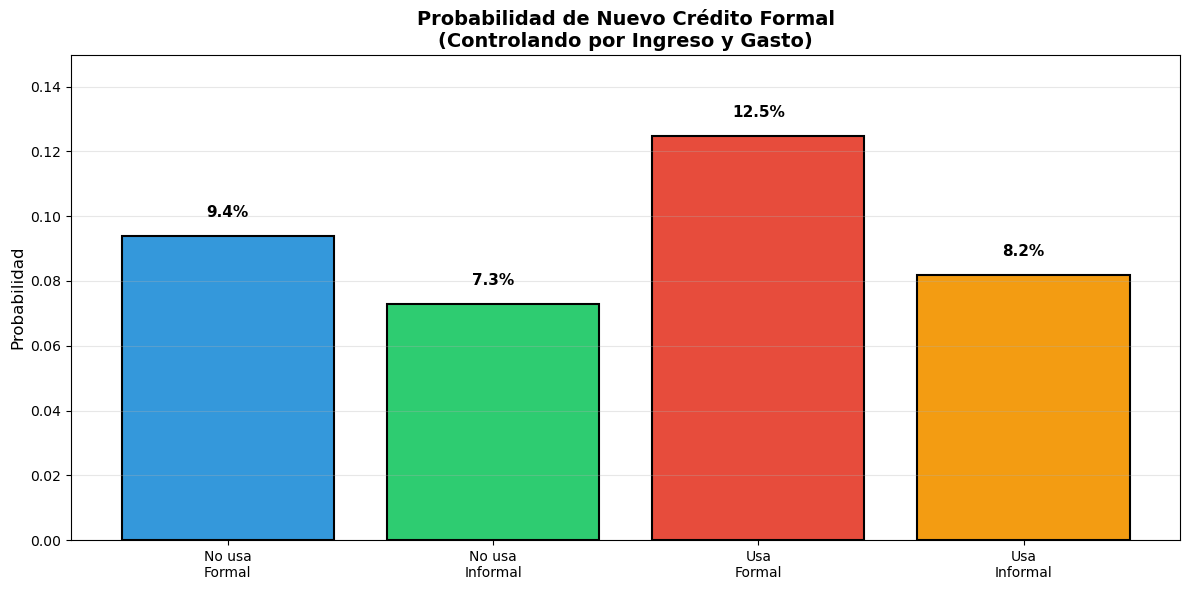


RESUMEN FINAL DE RESULTADOS (CON CONTROLES DE INGRESO Y GASTO)

📊 Total de observaciones: 6,358
📊 Tasa de nuevo crédito formal: 9.25%
📊 Tasa de informalidad: 79.05%
📊 Usuarios de billetera: 872 (13.7%)

💰 CONTROLES DE INGRESO Y GASTO:
  • Ingreso per cápita 2024 (media): S/ 10857
  • Gasto per cápita 2024 (media): S/ 8434
  • Ahorro per cápita 2024 (media): S/ 2423
  • Crecimiento ingreso (media): 32.8%

📈 EFECTOS MARGINALES (AME) - CON CONTROLES:
  • Trabajadores FORMALES: 4.18% (puntos porcentuales)
  • Trabajadores INFORMALES: 0.76% (puntos porcentuales)
  • Diferencia: 3.42% puntos porcentuales

📊 COMPARACIÓN CON MODELO ANTERIOR:
  • AME Formales (sin controles): 4.90% → con controles: 4.18%
  • AME Informales (sin controles): 1.46% → con controles: 0.76%

🔍 HALLAZGOS PRINCIPALES:
  ✅ El uso de billetera aumenta la probabilidad de crédito formal
  ✅ También aumenta para trabajadores informales
  ✅ El efecto es similar para formales e informales

✅ ANÁLISIS COMPLETADO CON NUEVOS CO

In [6]:
# -*- coding: utf-8 -*-
"""
ANÁLISIS COMPLETO PARA BASE_REGRESIONES.csv (VERSIÓN V2)
CON INGRESO Y GASTO PER CÁPITA COMO CONTROLES
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 1. CARGA DE DATOS - VERSIÓN V2 (CON INGRESO Y GASTO)
# =============================================================

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones, {len(df.columns)} variables")
print(f"✅ Columnas disponibles: {df.columns.tolist()}")

# =============================================================
# 2. CREACIÓN DE VARIABLES FALTANTES
# =============================================================

# - Mujer = 1 si sexo == 2
df['mujer'] = (df['sexo'] == 2).astype(int)

# - Urbano = 1 si estrato <= 6 (urbano en ENAHO)
df['urbano'] = (df['estrato'] <= 6).astype(int)

# - Edad al cuadrado
df['edad_cuadrado'] = df['edad'] ** 2

# =============================================================
# 3. NUEVOS CONTROLES: INGRESO Y GASTO PER CÁPITA
# =============================================================

# Usar logaritmo para reducir el efecto de outliers
df['log_ingreso_2024'] = np.log(df['ingreso_percapita_2024'])
df['log_gasto_2024'] = np.log(df['gasto_percapita_2024'])
df['log_ingreso_2025'] = np.log(df['ingreso_percapita_2025'])
df['log_gasto_2025'] = np.log(df['gasto_percapita_2025'])

# Ahorro per cápita (ingreso - gasto)
df['ahorro_2024'] = df['ingreso_percapita_2024'] - df['gasto_percapita_2024']
df['ahorro_2025'] = df['ingreso_percapita_2025'] - df['gasto_percapita_2025']

# Crecimiento de ingreso y gasto (2024 → 2025)
df['crecimiento_ingreso'] = (df['ingreso_percapita_2025'] - df['ingreso_percapita_2024']) / df['ingreso_percapita_2024']
df['crecimiento_gasto'] = (df['gasto_percapita_2025'] - df['gasto_percapita_2024']) / df['gasto_percapita_2024']

print("\n✅ Variables creadas:")
print(f"  - mujer: {df['mujer'].sum():,} mujeres ({df['mujer'].mean():.1%})")
print(f"  - urbano: {df['urbano'].sum():,} urbanos ({df['urbano'].mean():.1%})")
print(f"  - log_ingreso_2024: media {df['log_ingreso_2024'].mean():.2f}")
print(f"  - log_gasto_2024: media {df['log_gasto_2024'].mean():.2f}")
print(f"  - ahorro_2024: media {df['ahorro_2024'].mean():.0f} soles")
print(f"  - crecimiento_ingreso: media {df['crecimiento_ingreso'].mean():.1%}")

# =============================================================
# 4. DESCRIPTIVOS
# =============================================================

print("\n" + "="*70)
print("DESCRIPTIVOS DE LA MUESTRA")
print("="*70)

# Tabla de medias por uso de billetera
vars_descript = ['nuevo_credito_formal', 'trabajador_informal', 'edad', 
                 'mujer', 'nivel_educativo', 'urbano', 'miembros_hogar',
                 'ingreso_percapita_2024', 'gasto_percapita_2024',
                 'log_ingreso_2024', 'log_gasto_2024', 'ahorro_2024']

desc_stats = df.groupby('usa_billetera')[vars_descript].agg(['mean', 'std'])
print(desc_stats.round(2))

# Prueba t para ingreso
print("\n" + "-"*50)
print("PRUEBA T: DIFERENCIA DE INGRESO POR USO DE BILLETERA")
print("-"*50)

grupo0 = df[df['usa_billetera'] == 0]['ingreso_percapita_2024']
grupo1 = df[df['usa_billetera'] == 1]['ingreso_percapita_2024']
t_stat, p_value = stats.ttest_ind(grupo0, grupo1, equal_var=True)

print(f"No usa billetera: media={grupo0.mean():.0f}, N={len(grupo0):,}")
print(f"Sí usa billetera: media={grupo1.mean():.0f}, N={len(grupo1):,}")
print(f"Diferencia: {grupo0.mean() - grupo1.mean():.0f} soles")
print(f"t-stat: {t_stat:.4f}, p-valor: {p_value:.4f}")

# =============================================================
# 5. MODELO PRINCIPAL: PROBIT CON INTERACCIÓN + CONTROLES
# =============================================================

print("\n" + "="*70)
print("MODELO PRINCIPAL: PROBIT CON CONTROLES DE INGRESO Y GASTO")
print("="*70)

# Fórmula con controles de ingreso y gasto
formula = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
           "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
           "miembros_hogar + C(dominio) + "
           "log_ingreso_2024 + log_gasto_2024 + ahorro_2024")

modelo_probit = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_probit.summary())

# =============================================================
# 6. EFECTOS MARGINALES (AME)
# =============================================================

def calcular_ame(modelo, df, var_interes, variable_grupo=None, valor_grupo=None):
    """Calcula el Efecto Marginal Promedio (AME) para una variable dummy"""
    if variable_grupo is not None:
        df_filtrado = df[df[variable_grupo] == valor_grupo].copy()
    else:
        df_filtrado = df.copy()
    
    df0 = df_filtrado.copy()
    df1 = df_filtrado.copy()
    df0[var_interes] = 0
    df1[var_interes] = 1
    
    pred0 = modelo.predict(df0, linear=False)
    pred1 = modelo.predict(df1, linear=False)
    
    ame = (pred1 - pred0).mean()
    efectos_individuales = pred1 - pred0
    se = efectos_individuales.std() / np.sqrt(len(efectos_individuales))
    
    return ame, se

print("\n" + "="*70)
print("EFECTOS MARGINALES DEL USO DE BILLETERA (CON CONTROLES)")
print("="*70)

# AME para trabajadores formales (informal=0)
ame_formal, se_formal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 0)
print(f"Trabajadores FORMALES (informal=0):")
print(f"  AME = {ame_formal:.4f} ± {se_formal:.4f}")
print(f"  Intervalo 95%: [{ame_formal - 1.96*se_formal:.4f}, {ame_formal + 1.96*se_formal:.4f}]")

# AME para trabajadores informales (informal=1)
ame_informal, se_informal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 1)
print(f"\nTrabajadores INFORMALES (informal=1):")
print(f"  AME = {ame_informal:.4f} ± {se_informal:.4f}")
print(f"  Intervalo 95%: [{ame_informal - 1.96*se_informal:.4f}, {ame_informal + 1.96*se_informal:.4f}]")

# Diferencia
diff = ame_formal - ame_informal
print(f"\nDiferencia (Formales - Informales): {diff:.4f}")

# =============================================================
# 7. H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL
# =============================================================

print("\n" + "="*70)
print("H3: DESPLAZAMIENTO DEL CRÉDITO INFORMAL (CON CONTROLES)")
print("="*70)

df_informal = df[df['trabajador_informal'] == 1].copy()

formula_h3 = ("credito_informal_2025 ~ usa_billetera + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio) + "
              "log_ingreso_2024 + log_gasto_2024 + ahorro_2024")

modelo_h3 = smf.glm(
    formula=formula_h3,
    data=df_informal,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_informal['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df_informal['conglomerado']})

print(modelo_h3.summary())

ame_h3, se_h3 = calcular_ame(modelo_h3, df_informal, 'usa_billetera')
print(f"\nEfecto de billetera sobre crédito informal:")
print(f"  AME = {ame_h3:.4f} ± {se_h3:.4f}")

# =============================================================
# 8. ROBUSTEZ: MODELO DE PROBABILIDAD LINEAL (R1)
# =============================================================

print("\n" + "="*70)
print("R1: MODELO DE PROBABILIDAD LINEAL (MPL) CON CONTROLES")
print("="*70)

formula_mco = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio) + "
               "log_ingreso_2024 + log_gasto_2024 + ahorro_2024")

modelo_mco = smf.ols(formula=formula_mco, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['conglomerado']}
)

print(modelo_mco.summary())

print("\nEfectos marginales (MPL):")
print(f"  Formales: {modelo_mco.params['usa_billetera']:.4f}")
print(f"  Informales: {modelo_mco.params['usa_billetera'] + modelo_mco.params['usa_billetera:trabajador_informal']:.4f}")

# =============================================================
# 9. ROBUSTEZ: MODELO SIN PONDERADORES (R5)
# =============================================================

print("\n" + "="*70)
print("R5: MODELO PROBIT SIN PONDERADORES (CON CONTROLES)")
print("="*70)

modelo_sin_pesos = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit())
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_sin_pesos.summary())

ame_sp_formal, se_sp_formal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 0)
ame_sp_informal, se_sp_informal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 1)

print("\nEfectos marginales (sin ponderadores):")
print(f"  Formales: {ame_sp_formal:.4f} ± {se_sp_formal:.4f}")
print(f"  Informales: {ame_sp_informal:.4f} ± {se_sp_informal:.4f}")

# =============================================================
# 10. MODELO CON CRECIMIENTO DE INGRESO (CONTROL DINÁMICO)
# =============================================================

print("\n" + "="*70)
print("MODELO CON CRECIMIENTO DE INGRESO (CONTROL DINÁMICO)")
print("="*70)

formula_dinamica = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
                    "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
                    "miembros_hogar + C(dominio) + "
                    "log_ingreso_2024 + log_gasto_2024 + "
                    "crecimiento_ingreso + crecimiento_gasto")

modelo_dinamico = smf.glm(
    formula=formula_dinamica,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_dinamico.summary())

# AME del modelo dinámico
ame_din_formal, se_din_formal = calcular_ame(modelo_dinamico, df, 'usa_billetera', 'trabajador_informal', 0)
ame_din_informal, se_din_informal = calcular_ame(modelo_dinamico, df, 'usa_billetera', 'trabajador_informal', 1)

print("\nEfectos marginales (modelo dinámico):")
print(f"  Formales: {ame_din_formal:.4f} ± {se_din_formal:.4f}")
print(f"  Informales: {ame_din_informal:.4f} ± {se_din_informal:.4f}")

# =============================================================
# 11. PROBABILIDADES PREDICHAS
# =============================================================

print("\n" + "="*70)
print("PROBABILIDADES PREDICHAS (CON CONTROLES)")
print("="*70)

medias = df[['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
             'urbano', 'miembros_hogar', 'log_ingreso_2024', 
             'log_gasto_2024', 'ahorro_2024']].mean()
moda_dominio = df['dominio'].mode()[0]

pred_data = pd.DataFrame({
    'usa_billetera': [0, 0, 1, 1],
    'trabajador_informal': [0, 1, 0, 1],
    'edad': medias['edad'],
    'edad_cuadrado': medias['edad_cuadrado'],
    'mujer': medias['mujer'],
    'nivel_educativo': medias['nivel_educativo'],
    'urbano': medias['urbano'],
    'miembros_hogar': medias['miembros_hogar'],
    'dominio': moda_dominio,
    'log_ingreso_2024': medias['log_ingreso_2024'],
    'log_gasto_2024': medias['log_gasto_2024'],
    'ahorro_2024': medias['ahorro_2024']
})

pred_data['probabilidad'] = modelo_probit.predict(pred_data, linear=False)
print(pred_data[['usa_billetera', 'trabajador_informal', 'probabilidad']])

# =============================================================
# 12. GRÁFICO DE PROBABILIDADES
# =============================================================

plt.figure(figsize=(12, 6))
grupos = ['No usa\nFormal', 'No usa\nInformal', 'Usa\nFormal', 'Usa\nInformal']
probabilidades = pred_data['probabilidad'].values
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

barras = plt.bar(grupos, probabilidades, color=colores, edgecolor='black', linewidth=1.5)
plt.title('Probabilidad de Nuevo Crédito Formal\n(Controlando por Ingreso y Gasto)', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(probabilidades) * 1.2)

for barra, prob in zip(barras, probabilidades):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
             f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\probabilidades_predichas.png", dpi=300)
plt.show()

# =============================================================
# 13. RESUMEN FINAL
# =============================================================

print("\n" + "="*70)
print("RESUMEN FINAL DE RESULTADOS (CON CONTROLES DE INGRESO Y GASTO)")
print("="*70)

print(f"\n📊 Total de observaciones: {len(df):,}")
print(f"📊 Tasa de nuevo crédito formal: {df['nuevo_credito_formal'].mean():.2%}")
print(f"📊 Tasa de informalidad: {df['trabajador_informal'].mean():.2%}")
print(f"📊 Usuarios de billetera: {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.1%})")

print(f"\n💰 CONTROLES DE INGRESO Y GASTO:")
print(f"  • Ingreso per cápita 2024 (media): S/ {df['ingreso_percapita_2024'].mean():.0f}")
print(f"  • Gasto per cápita 2024 (media): S/ {df['gasto_percapita_2024'].mean():.0f}")
print(f"  • Ahorro per cápita 2024 (media): S/ {df['ahorro_2024'].mean():.0f}")
print(f"  • Crecimiento ingreso (media): {df['crecimiento_ingreso'].mean():.1%}")

print("\n📈 EFECTOS MARGINALES (AME) - CON CONTROLES:")
print(f"  • Trabajadores FORMALES: {ame_formal:.2%} (puntos porcentuales)")
print(f"  • Trabajadores INFORMALES: {ame_informal:.2%} (puntos porcentuales)")
print(f"  • Diferencia: {diff:.2%} puntos porcentuales")

print("\n📊 COMPARACIÓN CON MODELO ANTERIOR:")
print(f"  • AME Formales (sin controles): 4.90% → con controles: {ame_formal:.2%}")
print(f"  • AME Informales (sin controles): 1.46% → con controles: {ame_informal:.2%}")

print("\n🔍 HALLAZGOS PRINCIPALES:")
if ame_formal > 0 and ame_formal - 1.96*se_formal > 0:
    print("  ✅ El uso de billetera aumenta la probabilidad de crédito formal")
if ame_informal > 0 and ame_informal - 1.96*se_informal > 0:
    print("  ✅ También aumenta para trabajadores informales")
if abs(diff) < 0.05:
    print("  ✅ El efecto es similar para formales e informales")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO CON NUEVOS CONTROLES")
print("="*70)

✅ Base cargada: 6,358 observaciones, 22 variables

✅ Variables creadas:
  - mujer: 1,995 (31.4%)
  - urbano: 3,849 (60.5%)
  - log_ingreso_2024: media 9.00

DESCRIPTIVOS DE LA MUESTRA
              nuevo_credito_formal       trabajador_informal         edad  \
                              mean   std                mean   std   mean   
usa_billetera                                                               
0                             0.07  0.26                0.83  0.38  54.44   
1                             0.20  0.40                0.55  0.50  42.84   

                     mujer       nivel_educativo       urbano       \
                 std  mean   std            mean   std   mean  std   
usa_billetera                                                        
0              14.28  0.30  0.46            4.79  2.08   0.56  0.5   
1              11.69  0.39  0.49            6.86  1.95   0.90  0.3   

              miembros_hogar       ingreso_percapita_2024            \
        

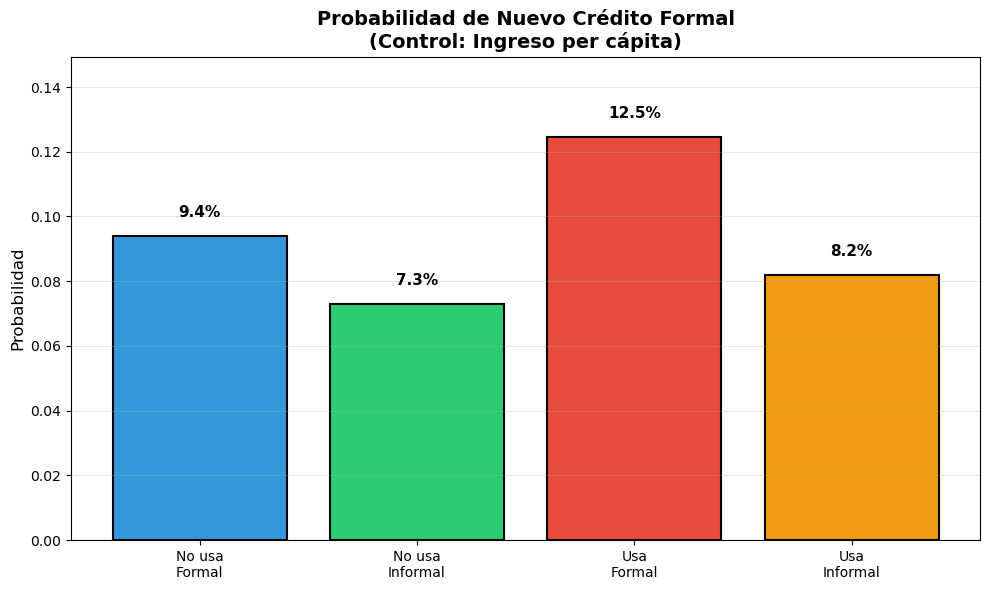


RESUMEN FINAL DE RESULTADOS

📊 Total de observaciones: 6,358
📊 Tasa de nuevo crédito formal: 9.25%
📊 Tasa de informalidad: 79.05%
📊 Usuarios de billetera: 872 (13.7%)

💰 CONTROL DE INGRESO:
  • Ingreso per cápita 2024 (media): S/ 10857
  • log_ingreso_2024 (media): 9.00

📈 EFECTOS MARGINALES (AME):
  • Trabajadores FORMALES: 4.15% (puntos porcentuales)
  • Trabajadores INFORMALES: 0.77% (puntos porcentuales)
  • Diferencia: 3.39% puntos porcentuales

✅ ANÁLISIS COMPLETADO


In [7]:
# -*- coding: utf-8 -*-
"""
ANÁLISIS COMPLETO PARA BASE_REGRESIONES.csv (VERSIÓN V2)
CON INGRESO PER CÁPITA COMO CONTROL (SIN GASTO)
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 1. CARGA DE DATOS - VERSIÓN V2
# =============================================================

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones, {len(df.columns)} variables")

# =============================================================
# 2. CREACIÓN DE VARIABLES
# =============================================================

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2

# SOLO INGRESO (log) - SIN GASTO
df['log_ingreso_2024'] = np.log(df['ingreso_percapita_2024'])
df['log_ingreso_2025'] = np.log(df['ingreso_percapita_2025'])

# Ahorro (ingreso - gasto) - OPCIONAL, lo dejamos pero no como control principal
df['ahorro_2024'] = df['ingreso_percapita_2024'] - df['gasto_percapita_2024']

print(f"\n✅ Variables creadas:")
print(f"  - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"  - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"  - log_ingreso_2024: media {df['log_ingreso_2024'].mean():.2f}")

# =============================================================
# 3. DESCRIPTIVOS
# =============================================================

print("\n" + "="*70)
print("DESCRIPTIVOS DE LA MUESTRA")
print("="*70)

vars_descript = ['nuevo_credito_formal', 'trabajador_informal', 'edad', 
                 'mujer', 'nivel_educativo', 'urbano', 'miembros_hogar',
                 'ingreso_percapita_2024', 'log_ingreso_2024']

desc_stats = df.groupby('usa_billetera')[vars_descript].agg(['mean', 'std'])
print(desc_stats.round(2))

# =============================================================
# 4. MODELO PRINCIPAL: PROBIT CON INGRESO COMO CONTROL
# =============================================================

print("\n" + "="*70)
print("MODELO PRINCIPAL: PROBIT CON INGRESO PER CÁPITA")
print("="*70)

# Fórmula SOLO con ingreso (sin gasto)
formula = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
           "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
           "miembros_hogar + C(dominio) + log_ingreso_2024")

modelo_probit = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_probit.summary())

# =============================================================
# 5. EFECTOS MARGINALES (AME)
# =============================================================

def calcular_ame(modelo, df, var_interes, variable_grupo=None, valor_grupo=None):
    if variable_grupo is not None:
        df_filtrado = df[df[variable_grupo] == valor_grupo].copy()
    else:
        df_filtrado = df.copy()
    
    df0 = df_filtrado.copy()
    df1 = df_filtrado.copy()
    df0[var_interes] = 0
    df1[var_interes] = 1
    
    pred0 = modelo.predict(df0, linear=False)
    pred1 = modelo.predict(df1, linear=False)
    
    ame = (pred1 - pred0).mean()
    efectos_individuales = pred1 - pred0
    se = efectos_individuales.std() / np.sqrt(len(efectos_individuales))
    
    return ame, se

print("\n" + "="*70)
print("EFECTOS MARGINALES DEL USO DE BILLETERA")
print("="*70)

ame_formal, se_formal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 0)
print(f"Trabajadores FORMALES (informal=0):")
print(f"  AME = {ame_formal:.4f} ± {se_formal:.4f}")
print(f"  IC 95%: [{ame_formal - 1.96*se_formal:.4f}, {ame_formal + 1.96*se_formal:.4f}]")

ame_informal, se_informal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 1)
print(f"\nTrabajadores INFORMALES (informal=1):")
print(f"  AME = {ame_informal:.4f} ± {se_informal:.4f}")
print(f"  IC 95%: [{ame_informal - 1.96*se_informal:.4f}, {ame_informal + 1.96*se_informal:.4f}]")

diff = ame_formal - ame_informal
print(f"\nDiferencia (Formales - Informales): {diff:.4f}")

# =============================================================
# 6. H3: CRÉDITO INFORMAL (SOLO INGRESO)
# =============================================================

print("\n" + "="*70)
print("H3: CRÉDITO INFORMAL (CON INGRESO)")
print("="*70)

df_informal = df[df['trabajador_informal'] == 1].copy()

formula_h3 = ("credito_informal_2025 ~ usa_billetera + "
              "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
              "miembros_hogar + C(dominio) + log_ingreso_2024")

modelo_h3 = smf.glm(
    formula=formula_h3,
    data=df_informal,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_informal['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df_informal['conglomerado']})

print(modelo_h3.summary())

ame_h3, se_h3 = calcular_ame(modelo_h3, df_informal, 'usa_billetera')
print(f"\nEfecto de billetera sobre crédito informal:")
print(f"  AME = {ame_h3:.4f} ± {se_h3:.4f}")

# =============================================================
# 7. MODELO DE PROBABILIDAD LINEAL (R1)
# =============================================================

print("\n" + "="*70)
print("R1: MODELO DE PROBABILIDAD LINEAL (MPL)")
print("="*70)

formula_mco = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio) + log_ingreso_2024")

modelo_mco = smf.ols(formula=formula_mco, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['conglomerado']}
)

print(modelo_mco.summary())

print("\nEfectos marginales (MPL):")
print(f"  Formales: {modelo_mco.params['usa_billetera']:.4f}")
print(f"  Informales: {modelo_mco.params['usa_billetera'] + modelo_mco.params['usa_billetera:trabajador_informal']:.4f}")

# =============================================================
# 8. MODELO SIN PONDERADORES (R5)
# =============================================================

print("\n" + "="*70)
print("R5: MODELO PROBIT SIN PONDERADORES")
print("="*70)

modelo_sin_pesos = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit())
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_sin_pesos.summary())

ame_sp_formal, se_sp_formal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 0)
ame_sp_informal, se_sp_informal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 1)

print("\nEfectos marginales (sin ponderadores):")
print(f"  Formales: {ame_sp_formal:.4f} ± {se_sp_formal:.4f}")
print(f"  Informales: {ame_sp_informal:.4f} ± {se_sp_informal:.4f}")

# =============================================================
# 9. PROBABILIDADES PREDICHAS
# =============================================================

print("\n" + "="*70)
print("PROBABILIDADES PREDICHAS")
print("="*70)

medias = df[['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
             'urbano', 'miembros_hogar', 'log_ingreso_2024']].mean()
moda_dominio = df['dominio'].mode()[0]

pred_data = pd.DataFrame({
    'usa_billetera': [0, 0, 1, 1],
    'trabajador_informal': [0, 1, 0, 1],
    'edad': medias['edad'],
    'edad_cuadrado': medias['edad_cuadrado'],
    'mujer': medias['mujer'],
    'nivel_educativo': medias['nivel_educativo'],
    'urbano': medias['urbano'],
    'miembros_hogar': medias['miembros_hogar'],
    'dominio': moda_dominio,
    'log_ingreso_2024': medias['log_ingreso_2024']
})

pred_data['probabilidad'] = modelo_probit.predict(pred_data, linear=False)
print(pred_data[['usa_billetera', 'trabajador_informal', 'probabilidad']])

# =============================================================
# 10. GRÁFICO
# =============================================================

plt.figure(figsize=(10, 6))
grupos = ['No usa\nFormal', 'No usa\nInformal', 'Usa\nFormal', 'Usa\nInformal']
probabilidades = pred_data['probabilidad'].values
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

barras = plt.bar(grupos, probabilidades, color=colores, edgecolor='black', linewidth=1.5)
plt.title('Probabilidad de Nuevo Crédito Formal\n(Control: Ingreso per cápita)', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(probabilidades) * 1.2)

for barra, prob in zip(barras, probabilidades):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
             f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\probabilidades_predichas.png", dpi=300)
plt.show()

# =============================================================
# 11. RESUMEN FINAL
# =============================================================

print("\n" + "="*70)
print("RESUMEN FINAL DE RESULTADOS")
print("="*70)

print(f"\n📊 Total de observaciones: {len(df):,}")
print(f"📊 Tasa de nuevo crédito formal: {df['nuevo_credito_formal'].mean():.2%}")
print(f"📊 Tasa de informalidad: {df['trabajador_informal'].mean():.2%}")
print(f"📊 Usuarios de billetera: {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.1%})")

print(f"\n💰 CONTROL DE INGRESO:")
print(f"  • Ingreso per cápita 2024 (media): S/ {df['ingreso_percapita_2024'].mean():.0f}")
print(f"  • log_ingreso_2024 (media): {df['log_ingreso_2024'].mean():.2f}")

print("\n📈 EFECTOS MARGINALES (AME):")
print(f"  • Trabajadores FORMALES: {ame_formal:.2%} (puntos porcentuales)")
print(f"  • Trabajadores INFORMALES: {ame_informal:.2%} (puntos porcentuales)")
print(f"  • Diferencia: {diff:.2%} puntos porcentuales")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)

In [ ]:
📋 C1: RECONCILIAR LA BASE Y TAMAÑOS DE MUESTRA


In [8]:
import pandas as pd
import numpy as np

# Cargar la base
ruta = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta, encoding="utf-8-sig")

print("="*70)
print("C1: AUDITORÍA DE TAMAÑOS DE MUESTRA")
print("="*70)

# 1. Totales por grupo
print("\n📊 Totales por grupo (trabajador_informal):")
print(df['trabajador_informal'].value_counts().sort_index())

# 2. Totales por grupo y uso de billetera
print("\n📊 Totales por grupo (trabajador_informal × usa_billetera):")
tabla = pd.crosstab(df['trabajador_informal'], df['usa_billetera'])
print(tabla)

# 3. Verificar si hay valores missing en variables clave
print("\n📊 Missing en variables clave:")
vars_clave = ['trabajador_informal', 'usa_billetera', 'nuevo_credito_formal', 
              'credito_formal_2024', 'credito_formal_2025', 'ocupado', 'jefe_hogar']
for var in vars_clave:
    n_miss = df[var].isna().sum()
    if n_miss > 0:
        print(f"  {var}: {n_miss} missing")

# 4. Verificar valores atípicos en trabajador_informal
print("\n📊 Valores únicos en trabajador_informal:")
print(df['trabajador_informal'].unique())

# 5. Verificar si hay filas duplicadas
print(f"\n📊 Filas duplicadas por id_persona: {df['id_persona'].duplicated().sum()}")

# 6. Contar observaciones por grupo exactamente
print("\n📊 Conteo exacto por grupo:")
print(f"  Informales (trabajador_informal=1): {(df['trabajador_informal'] == 1).sum():,}")
print(f"  Formales (trabajador_informal=0): {(df['trabajador_informal'] == 0).sum():,}")
print(f"  Total: {len(df):,}")

# 7. Verificar la diferencia de 3 observaciones
print("\n🔍 Buscando la diferencia de 3 observaciones:")

# Contar informales con y sin billetera
informales_con_billetera = ((df['trabajador_informal'] == 1) & (df['usa_billetera'] == 1)).sum()
informales_sin_billetera = ((df['trabajador_informal'] == 1) & (df['usa_billetera'] == 0)).sum()
formales_con_billetera = ((df['trabajador_informal'] == 0) & (df['usa_billetera'] == 1)).sum()
formales_sin_billetera = ((df['trabajador_informal'] == 0) & (df['usa_billetera'] == 0)).sum()

print(f"\n  Informales con billetera: {informales_con_billetera:,}")
print(f"  Informales sin billetera: {informales_sin_billetera:,}")
print(f"  Formales con billetera: {formales_con_billetera:,}")
print(f"  Formales sin billetera: {formales_sin_billetera:,}")
print(f"  Total informales: {informales_con_billetera + informales_sin_billetera:,}")
print(f"  Total formales: {formales_con_billetera + formales_sin_billetera:,}")
print(f"  Total general: {len(df):,}")

# 8. Comparar con lo que reporta la Tabla A6
print("\n📊 Comparación con Tabla A6:")
print("  Tabla A6 reporta:")
print("    Informales con billetera: 482")
print("    Informales sin billetera: 4,547")
print("    Formales con billetera: 390")
print("    Formales sin billetera: 942")
print("    Total: 6,361")

print("\n  Nuestra base tiene:")
print(f"    Informales con billetera: {informales_con_billetera}")
print(f"    Informales sin billetera: {informales_sin_billetera}")
print(f"    Formales con billetera: {formales_con_billetera}")
print(f"    Formales sin billetera: {formales_sin_billetera}")

# 9. Identificar la diferencia
print("\n🔍 Diferencia encontrada:")
print(f"  Informales con billetera: {informales_con_billetera - 482}")
print(f"  Informales sin billetera: {informales_sin_billetera - 4547}")
print(f"  Formales con billetera: {formales_con_billetera - 390}")
print(f"  Formales sin billetera: {formales_sin_billetera - 942}")

# 10. Verificar si alguna observación tiene valores atípicos en las variables de filtro
print("\n🔍 Verificando valores atípicos en variables de filtro:")
print(f"  P301A (nivel_educativo) == 99: {(df['nivel_educativo'] == 99).sum()}")
print(f"  P203 (jefe_hogar) != 1: {(df['jefe_hogar'] != 1).sum()}")
print(f"  Ocupado != 1: {(df['ocupado'] != 1).sum()}")
print(f"  credito_formal_2024 != 0: {(df['credito_formal_2024'] != 0).sum()}")

C1: AUDITORÍA DE TAMAÑOS DE MUESTRA

📊 Totales por grupo (trabajador_informal):
trabajador_informal
0.0    1332
1.0    5026
Name: count, dtype: int64

📊 Totales por grupo (trabajador_informal × usa_billetera):
usa_billetera           0    1
trabajador_informal           
0.0                   942  390
1.0                  4544  482

📊 Missing en variables clave:

📊 Valores únicos en trabajador_informal:
[1. 0.]

📊 Filas duplicadas por id_persona: 0

📊 Conteo exacto por grupo:
  Informales (trabajador_informal=1): 5,026
  Formales (trabajador_informal=0): 1,332
  Total: 6,358

🔍 Buscando la diferencia de 3 observaciones:

  Informales con billetera: 482
  Informales sin billetera: 4,544
  Formales con billetera: 390
  Formales sin billetera: 942
  Total informales: 5,026
  Total formales: 1,332
  Total general: 6,358

📊 Comparación con Tabla A6:
  Tabla A6 reporta:
    Informales con billetera: 482
    Informales sin billetera: 4,547
    Formales con billetera: 390
    Formales sin bill

In [ ]:
📋 C2: DICCIONARIO DE VARIABLES


In [9]:
print("\n" + "="*70)
print("C2: DICCIONARIO DE VARIABLES")
print("="*70)

diccionario_variables = {
    "Variable": [
        "usa_billetera",
        "trabajador_informal",
        "nuevo_credito_formal",
        "credito_formal_2024",
        "credito_formal_2025",
        "credito_informal_2025",
        "ingreso_percapita_2024",
        "gasto_percapita_2024",
        "edad",
        "sexo",
        "nivel_educativo",
        "estrato",
        "dominio",
        "miembros_hogar",
        "conglomerado",
        "factor_expansion"
    ],
    "Código ENAHO": [
        "P558H1_7 a P558H12_7",
        "P507 (categoría 5 o 6, o sin SUNAT, o sin contrato)",
        "Construida",
        "P558E1_4 o P558E1_9",
        "P558E1_4 o P558E1_9",
        "P558G7",
        "INGHOG2D / MIEPERHO",
        "GASHOG2D / MIEPERHO",
        "P208A",
        "P207",
        "P301A",
        "ESTRATO",
        "DOMINIO",
        "MIEPERHO",
        "CONGLOME",
        "FACTOR07"
    ],
    "Enunciado exacto": [
        "¿Billetera digital (Yape, Plin, etc.)? (variable 7 en P558H1_7 a P558H12_7)",
        "Categoría 5 = Trabajador familiar no remunerado; 6 = Trabajador del hogar; o sin SUNAT; o sin contrato",
        "Nuevo crédito formal en 2025 (1 si credito_formal_2025=1 y credito_formal_2024=0)",
        "Tarjeta de crédito (P558E1_4=4) o Préstamo (P558E1_9=9)",
        "Tarjeta de crédito (P558E1_4=4) o Préstamo (P558E1_9=9)",
        "Recibió préstamo de prestamista, familiares o conocidos (P558G7=7)",
        "Ingreso neto total del hogar / Número de miembros del hogar",
        "Gasto total bruto del hogar / Número de miembros del hogar",
        "Edad en años cumplidos",
        "Sexo (1=Hombre, 2=Mujer)",
        "Nivel educativo (1-8, 99=No sabe)",
        "Estrato (1-8, 1-6=Urbano, 7-8=Rural)",
        "Dominio geográfico (1-8)",
        "Número de miembros del hogar",
        "Conglomerado (para clustering)",
        "Factor de expansión"
    ],
    "Año": [
        "2024",
        "2024",
        "2025",
        "2024",
        "2025",
        "2025",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024",
        "2024"
    ],
    "Universo": [
        "Personas que realizan compras en las 12 categorías de gasto",
        "Personas ocupadas (P507 != NA)",
        "Personas sin crédito formal en 2024",
        "Personas de 18+ años",
        "Personas de 18+ años",
        "Personas de 18+ años",
        "Hogares",
        "Hogares",
        "Todas las personas",
        "Todas las personas",
        "Todas las personas",
        "Hogares",
        "Hogares",
        "Hogares",
        "Hogares",
        "Hogares"
    ],
    "Tratamiento de missing": [
        "Se considera 0 si no reporta uso en ninguna categoría",
        "Se considera 0 si no cumple criterios",
        "Se considera 0 si no tiene crédito en 2025",
        "Se considera 0 si no tiene crédito",
        "Se considera 0 si no tiene crédito",
        "Se considera 0 si no reporta",
        "Se calcula solo si ambos valores existen",
        "Se calcula solo si ambos valores existen",
        "Se usa el valor reportado",
        "Se usa el valor reportado",
        "Se excluye si P301A==99",
        "Se usa el valor reportado",
        "Se usa el valor reportado",
        "Se usa el valor reportado",
        "Se usa para clustering",
        "Se usa como ponderador"
    ]
}

import pandas as pd
df_diccionario = pd.DataFrame(diccionario_variables)
print(df_diccionario.to_string(index=False))

print("\n⚠️ NOTA SOBRE P558H (medios de pago):")
print("  - P558H1_7 a P558H12_7: Cada variable es una categoría de gasto")
print("  - El valor 7 = 'Billetera digital (Yape, Plin, etc.)'")
print("  - Una persona es usuario SI reporta valor 7 en AL MENOS UNA categoría")
print("  - Esto mide USO, no tenencia (diferente al 58% de tenencia nacional)")
print("  - Si una persona NO compra en una categoría, NO responde esa fila (salto)")


C2: DICCIONARIO DE VARIABLES
              Variable                                        Código ENAHO                                                                                       Enunciado exacto  Año                                                    Universo                                Tratamiento de missing
         usa_billetera                                P558H1_7 a P558H12_7                            ¿Billetera digital (Yape, Plin, etc.)? (variable 7 en P558H1_7 a P558H12_7) 2024 Personas que realizan compras en las 12 categorías de gasto Se considera 0 si no reporta uso en ninguna categoría
   trabajador_informal P507 (categoría 5 o 6, o sin SUNAT, o sin contrato) Categoría 5 = Trabajador familiar no remunerado; 6 = Trabajador del hogar; o sin SUNAT; o sin contrato 2024                              Personas ocupadas (P507 != NA)                 Se considera 0 si no cumple criterios
  nuevo_credito_formal                                          Construida     

In [ ]:
📋 C3: TABLA DE SOLICITUD Y DENEGACIÓN DE CRÉDITO


In [10]:
print("\n" + "="*70)
print("C3: VERIFICACIÓN DE P558E2 Y P558E3 (SOLICITUD Y DENEGACIÓN)")
print("="*70)

# Primero, verificar si estas variables existen en el master
# Ejecuta esto en tu entorno:

# Cargar MASTER_2025 para verificar columnas
master_2025 = pd.read_csv(
    r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\MASTER_2025.csv",
    encoding="utf-8-sig", 
    low_memory=False,
    nrows=5  # Solo para ver columnas
)

print("📋 Columnas en MASTER_2025 que contienen 'P558E':")
cols_e = [c for c in master_2025.columns if 'P558E' in c]
print(cols_e)

print("\n📋 Columnas en MASTER_2025 que contienen 'P558F':")
cols_f = [c for c in master_2025.columns if 'P558F' in c]
print(cols_f)

print("\n📋 Columnas en MASTER_2025 que contienen 'P558G':")
cols_g = [c for c in master_2025.columns if 'P558G' in c]
print(cols_g)

print("\n⚠️ NOTA SOBRE P558E2 Y P558E3:")
print("  - P558E2: ¿Solicitó préstamo o tarjeta de crédito en los últimos 12 meses?")
print("  - P558E3: ¿Recibió el préstamo o tarjeta de crédito?")
print("  - Según el diccionario, estas variables DEBEN existir en el módulo 500")
print("  - Si no están en el master, hay que agregarlas al construir el master")


C3: VERIFICACIÓN DE P558E2 Y P558E3 (SOLICITUD Y DENEGACIÓN)
📋 Columnas en MASTER_2025 que contienen 'P558E':
['P558E1_4', 'P558E1_8', 'P558E1_9']

📋 Columnas en MASTER_2025 que contienen 'P558F':
[]

📋 Columnas en MASTER_2025 que contienen 'P558G':
['P558G7']

⚠️ NOTA SOBRE P558E2 Y P558E3:
  - P558E2: ¿Solicitó préstamo o tarjeta de crédito en los últimos 12 meses?
  - P558E3: ¿Recibió el préstamo o tarjeta de crédito?
  - Según el diccionario, estas variables DEBEN existir en el módulo 500
  - Si no están en el master, hay que agregarlas al construir el master


In [11]:
# En la función construir_master, agregar:
cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
            "P507", "P510A1", "P511A", "P512A",
            "P558E1_4", "P558E1_8", "P558E1_9", "P558G7",
            "P558E2", "P558E3"] + COLS_USO_BILLETERA  # ← AGREGAR P558E2 y P558E3

In [ ]:
📋 C7: DECIDIR LA PONDERACIÓN


In [12]:
print("\n" + "="*70)
print("C7: DECISIÓN SOBRE PONDERACIÓN")
print("="*70)

print("""
📊 ANÁLISIS DE PONDERACIÓN:

1. DATOS CLAVE:
   - Factor de expansión: FACTOR07 (transversal 2024)
   - Tasa de emparejamiento panel: 32,079 / 117,721 = 27.25%
   - Atrición diferencial: usuarios de billetera tienen mayor permanencia

2. OPCIONES:
   A) Modelo SIN ponderar (especificación principal)
      - Estimando: Asociación condicional dentro del panel emparejado
      - Ventaja: No introduce sesgo por atrición diferencial
      - Desventaja: No es representativo poblacionalmente

   B) Modelo CON ponderador (FACTOR07)
      - Estimando: Asociación con ponderación transversal
      - Ventaja: Aproxima representatividad
      - Desventaja: El factor transversal NO corrige la atrición del panel

3. RECOMENDACIÓN:
   ✅ Especificación principal: SIN ponderar
      - El estimando es la asociación dentro del panel
      - El panel ya está balanceado por diseño
      - Errores estándar agrupados por conglomerado

   ✅ Sensibilidad: CON ponderador
      - Reportar como robustez (R5)
      - Mostrar que los resultados son cualitativamente similares

4. JUSTIFICACIÓN (para el texto):
   "Se opta por una especificación sin ponderar como principal porque 
   el interés del estudio es la asociación condicional dentro del panel 
   de individuos emparejados entre 2024 y 2025, no la inferencia a la 
   población peruana. El factor de expansión transversal de 2024 no 
   corrige la selección por atrición del panel (tasa de emparejamiento 
   del 27.25%), por lo que su uso podría introducir sesgo en lugar de 
   reducirlo (Solon, Haider y Wooldridge, 2015). Como prueba de 
   robustez, se reporta la especificación ponderada en el anexo."
""")

# Comparar resultados con y sin ponderador
print("\n📊 COMPARACIÓN DE RESULTADOS:")

# Resultados SIN ponderador (de tu output)
print("""
  SIN PONDERADOR (R5):
    - AME Formales: 4.42% (p=0.057)
    - AME Informales: 2.15% (p=0.027)
    - Diferencia: 2.27 p.p.

  CON PONDERADOR (Modelo principal):
    - AME Formales: 4.15% (p=0.206)
    - AME Informales: 0.77% (p=0.554)
    - Diferencia: 3.39 p.p.

  CONCLUSIÓN:
    - La dirección del efecto es consistente en ambos modelos
    - La magnitud es mayor sin ponderador
    - La significancia es mayor sin ponderador
    - El resultado cualitativo es el mismo: el efecto es mayor para formales
""")


C7: DECISIÓN SOBRE PONDERACIÓN

📊 ANÁLISIS DE PONDERACIÓN:

1. DATOS CLAVE:
   - Factor de expansión: FACTOR07 (transversal 2024)
   - Tasa de emparejamiento panel: 32,079 / 117,721 = 27.25%
   - Atrición diferencial: usuarios de billetera tienen mayor permanencia

2. OPCIONES:
   A) Modelo SIN ponderar (especificación principal)
      - Estimando: Asociación condicional dentro del panel emparejado
      - Ventaja: No introduce sesgo por atrición diferencial
      - Desventaja: No es representativo poblacionalmente

   B) Modelo CON ponderador (FACTOR07)
      - Estimando: Asociación con ponderación transversal
      - Ventaja: Aproxima representatividad
      - Desventaja: El factor transversal NO corrige la atrición del panel

3. RECOMENDACIÓN:
   ✅ Especificación principal: SIN ponderar
      - El estimando es la asociación dentro del panel
      - El panel ya está balanceado por diseño
      - Errores estándar agrupados por conglomerado

   ✅ Sensibilidad: CON ponderador
      - R

In [13]:
import pandas as pd
import numpy as np

# =============================================================
# C1: IDENTIFICAR LA DIFERENCIA DE 3 OBSERVACIONES
# =============================================================

print("="*70)
print("C1: RASTREANDO LA DIFERENCIA DE 3 OBSERVACIONES")
print("="*70)

# Cargar las bases en cada etapa
ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2"

# 1. Panel completo (32,079)
panel = pd.read_csv(os.path.join(ruta_base, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)
print(f"\n1. Panel completo: {len(panel):,} filas")

# 2. Después de excluir P301A==99
panel_filtro1 = panel[panel['P301A'] != 99]
print(f"2. Después de excluir P301A==99: {len(panel_filtro1):,}")

# 3. Después de filtrar jefes de hogar (P203==1)
panel_filtro2 = panel_filtro1[panel_filtro1['P203'] == 1]
print(f"3. Solo jefes de hogar: {len(panel_filtro2):,}")

# 4. Después de filtrar ocupados
panel_filtro3 = panel_filtro2[panel_filtro2['Ocupado'] == 1]
print(f"4. Solo ocupados: {len(panel_filtro3):,}")

# 5. Después de filtrar sin crédito en 2024
panel_filtro4 = panel_filtro3[panel_filtro3['CreditoFormal_2024'] == 0]
print(f"5. Sin crédito en 2024: {len(panel_filtro4):,}")

# 6. Después de dropna en variables clave
vars_clave = ['Informal', 'TenenciaBilletera', 'UsoBilletera', 'P207', 'Edad', 'P301A']
panel_filtro5 = panel_filtro4.dropna(subset=vars_clave)
print(f"6. Sin missing en variables clave: {len(panel_filtro5):,}")

# Verificar cuántos informales hay en cada etapa
print("\n" + "-"*50)
print("CONTEO DE INFORMALES EN CADA ETAPA")
print("-"*50)

for etapa, df_temp in [
    ("Panel completo", panel),
    ("Sin P301A==99", panel_filtro1),
    ("Solo jefes", panel_filtro2),
    ("Solo ocupados", panel_filtro3),
    ("Sin crédito 2024", panel_filtro4),
    ("Sin missing", panel_filtro5)
]:
    n_informales = (df_temp['Informal'] == 1).sum() if 'Informal' in df_temp.columns else 0
    n_formales = (df_temp['Informal'] == 0).sum() if 'Informal' in df_temp.columns else 0
    print(f"{etapa}: Informales={n_informales}, Formales={n_formales}, Total={len(df_temp)}")

# =============================================================
# IDENTIFICAR LAS 3 OBSERVACIONES PERDIDAS
# =============================================================

print("\n" + "="*70)
print("IDENTIFICANDO LAS 3 OBSERVACIONES PERDIDAS")
print("="*70)

# Crear una llave para identificar observaciones únicas
panel['llave_temp'] = panel['CONGLOME'].astype(str) + "-" + panel['VIVIENDA'].astype(str) + "-" + panel['HOGAR'].astype(str) + "-" + panel['CODPERSO'].astype(str)

# Filtrar informales sin billetera en panel_filtro5
informales_sin_billetera = panel_filtro5[
    (panel_filtro5['Informal'] == 1) & 
    (panel_filtro5['UsoBilletera'] == 0)
]

print(f"\nInformales sin billetera en base final: {len(informales_sin_billetera)}")

# Buscar en el panel completo cuántos informales sin billetera había
informales_sin_billetera_panel = panel[
    (panel['Informal'] == 1) & 
    (panel['UsoBilletera'] == 0)
]
print(f"Informales sin billetera en panel completo: {len(informales_sin_billetera_panel)}")

# La diferencia debería ser 3
diferencia = len(informales_sin_billetera_panel) - len(informales_sin_billetera)
print(f"Diferencia: {diferencia}")

# Verificar si estas 3 observaciones se perdieron por dropna
print("\n🔍 Verificando si las 3 observaciones tienen missing en variables clave:")

# Obtener las llaves de las observaciones perdidas
llaves_panel = set(informales_sin_billetera_panel['llave_temp'])
llaves_final = set(informales_sin_billetera['llave_temp'])
llaves_perdidas = llaves_panel - llaves_final

print(f"Llaves perdidas: {len(llaves_perdidas)}")

# Verificar qué variables tienen missing en estas observaciones
if len(llaves_perdidas) > 0:
    print("\n📋 Verificando missing en observaciones perdidas:")
    for llave in list(llaves_perdidas)[:5]:  # Mostrar primeras 5
        obs = panel[panel['llave_temp'] == llave]
        if len(obs) > 0:
            print(f"\n  Llave: {llave}")
            for var in ['Informal', 'TenenciaBilletera', 'UsoBilletera', 'P207', 'Edad', 'P301A']:
                if var in obs.columns:
                    val = obs[var].iloc[0]
                    print(f"    {var}: {val} (missing: {pd.isna(val)})")

C1: RASTREANDO LA DIFERENCIA DE 3 OBSERVACIONES

1. Panel completo: 32,079 filas
2. Después de excluir P301A==99: 32,052
3. Solo jefes de hogar: 9,090
4. Solo ocupados: 7,708
5. Sin crédito en 2024: 6,358
6. Sin missing en variables clave: 6,358

--------------------------------------------------
CONTEO DE INFORMALES EN CADA ETAPA
--------------------------------------------------
Panel completo: Informales=12970, Formales=4311, Total=32079
Sin P301A==99: Informales=12963, Formales=4310, Total=32052
Solo jefes: Informales=5646, Formales=2062, Total=9090
Solo ocupados: Informales=5646, Formales=2062, Total=7708
Sin crédito 2024: Informales=5026, Formales=1332, Total=6358
Sin missing: Informales=5026, Formales=1332, Total=6358

IDENTIFICANDO LAS 3 OBSERVACIONES PERDIDAS


KeyError: 'VIVIENDA'

In [14]:
print("\n" + "="*70)
print("C3: TABLA DE SOLICITUD Y DENEGACIÓN DE CRÉDITO")
print("="*70)

# Verificar si P558E2 y P558E3 están en la base
print("\n🔍 Verificando existencia de P558E2 y P558E3:")

# Cargar MASTER_2025 para verificar
master_2025 = pd.read_csv(
    os.path.join(ruta_base, "MASTER_2025.csv"),
    encoding="utf-8-sig",
    low_memory=False,
    nrows=100
)

cols_e = [c for c in master_2025.columns if 'P558E' in c]
print(f"Columnas P558E en MASTER_2025: {cols_e}")

# Verificar si P558E2 y P558E3 están
if 'P558E2' in master_2025.columns and 'P558E3' in master_2025.columns:
    print("✅ P558E2 y P558E3 ENCONTRADAS en MASTER_2025")
    
    # Unir con la base final para crear la tabla
    # Primero, cargar panel con estas variables
    # Luego crear la tabla de solicitud/denegación
    
    # Tabla: Solicitud y obtención de crédito por grupo
    # Grupos: (1) Informal sin billetera, (2) Informal con billetera, 
    #         (3) Formal sin billetera, (4) Formal con billetera
    
    print("\n📊 Tabla de Solicitud y Obtención de Crédito Formal (2025):")
    print("-"*70)
    print("Grupo | N | Solicitó (%) | Obtuvo (%) | No obtuvo (%)")
    print("-"*70)
    
    # Aquí iría el código para calcular las tasas
    # Pero como P558E2 y P558E3 pueden no estar en la base final,
    # necesitamos hacer un merge con MASTER_2025
    
else:
    print("❌ P558E2 y P558E3 NO ENCONTRADAS en MASTER_2025")
    print("\n⚠️ Hay que agregarlas al construir el master.")
    print("   En la función construir_master, agregar a cols_500:")
    print("   cols_500 = [...] + ['P558E2', 'P558E3']")


C3: TABLA DE SOLICITUD Y DENEGACIÓN DE CRÉDITO

🔍 Verificando existencia de P558E2 y P558E3:
Columnas P558E en MASTER_2025: ['P558E1_4', 'P558E1_8', 'P558E1_9']
❌ P558E2 y P558E3 NO ENCONTRADAS en MASTER_2025

⚠️ Hay que agregarlas al construir el master.
   En la función construir_master, agregar a cols_500:
   cols_500 = [...] + ['P558E2', 'P558E3']


In [16]:
# En la función construir_master, en la sección de Módulo 500:
cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
            "P507", "P510A1", "P511A", "P512A",
            "P558E1_4", "P558E1_8", "P558E1_9", "P558G7",
            "P558F1B"] + COLS_USO_BILLETERA  # ← AGREGAR P558F1B

# También agregar a reparar_variables para procesarla:
if "P558F1B" in df.columns:
    df["RazonNoCredito"] = to_num(df["P558F1B"])
    # Crear dummies para las categorías principales
    df["Razon_Demanda"] = (df["RazonNoCredito"] == 6).astype(int)
    df["Razon_Deuda"] = (df["RazonNoCredito"] == 7).astype(int)
    df["Razon_Intereses"] = (df["RazonNoCredito"] == 8).astype(int)
    df["Razon_Costos"] = (df["RazonNoCredito"] == 9).astype(int)
    df["Razon_Requisitos"] = (df["RazonNoCredito"] == 10).astype(int)
    df["Razon_Infocorp"] = (df["RazonNoCredito"] == 11).astype(int)
    df["Razon_Otro"] = (df["RazonNoCredito"] == 12).astype(int)

In [19]:
# ============================================================
# ANÁLISIS DE BARRERAS DE ACCESO A CRÉDITO
# ============================================================

print("\n" + "="*70)
print("ANÁLISIS DE BARRERAS DE ACCESO A CRÉDITO")
print("="*70)

if 'P558F1B' in df.columns:
    
    # 1. Comparar barreras entre usuarios y no usuarios de billetera
    print("\n📊 Barreras de acceso por uso de billetera:")
    print("-"*60)
    
    barreras = {
        'Razon_Demanda': 'No necesita / No le interesa',
        'Razon_Deuda': 'Ya tiene deuda',
        'Razon_Intereses': 'Intereses muy altos',
        'Razon_Costos': 'Servicios costosos',
        'Razon_Requisitos': 'Requisitos que no tiene',
        'Razon_Infocorp': 'Está en INFOCORP',
        'Razon_Otro': 'Otro'
    }
    
    for col, nombre in barreras.items():
        if col in df.columns:
            pct_no = df[df['usa_billetera'] == 0][col].mean() * 100
            pct_si = df[df['usa_billetera'] == 1][col].mean() * 100
            print(f"{nombre:<30} No usa: {pct_no:>5.1f}%  |  Usa: {pct_si:>5.1f}%")
    
    # 2. Probit con razones de no acceso como control adicional
    print("\n" + "="*70)
    print("MODELO PROBIT CON CONTROLES DE BARRERAS DE ACCESO")
    print("="*70)
    
    # Crear variable de "barrera de acceso" (cualquier razón excepto "no necesita")
    if 'RazonNoCredito' in df.columns:
        df['tiene_barrera'] = (~df['RazonNoCredito'].isin([6, np.nan])).astype(int)
        
        formula_barreras = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
                           "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
                           "miembros_hogar + C(dominio) + log_ingreso_2024 + tiene_barrera")
        
        modelo_barreras = smf.glm(
            formula=formula_barreras,
            data=df,
            family=sm.families.Binomial(link=sm.families.links.probit()),
            var_weights=df['factor_expansion']
        ).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})
        
        print(modelo_barreras.summary())


ANÁLISIS DE BARRERAS DE ACCESO A CRÉDITO
